In [2]:
import os
import sys
import gc
import base64
import joblib 
import itertools
from io import BytesIO
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
from functools import reduce

import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

from joblib import Parallel, delayed
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score
from sklearn.feature_selection import f_classif, mutual_info_classif
from scipy.stats import kruskal
import tensorflow as tf
from cycler import cycler
from matplotlib.colors import to_hex

import pickle

import config
EXCLUDED_FEATURES = config.EXCLUDED_FEATURES.copy()
FEATURE_GROUPS = config.FEATURE_GROUPS.copy()
curve_split = config.CURVE_SPLIT.copy()
metrics = config.IMPORTANCE_METRICS.copy()


[*] SUCCESS: TensorFlow is utilizing the GPU -> /physical_device:GPU:0



In [3]:
# ['ori_curves',
#   'ori_curves_avg',
#   'original_fitted_full',
#   'original_fitted_stretched',
#   'cleaned_std_fitted_full',
#   'cleaned_std_fitted_stretched',
#   'cleaned_lowest_fitted_full',
#   'cleaned_lowest_fitted_stretched',
#   'avg_lowest_fitted_full',
#   'avg_lowest_fitted_stretched',
#   'avg_cleaned_std_lowest_fitted_full',
#   'avg_cleaned_std_lowest_fitted_stretched',
#   'avg_cleaned_lowest_lowest_fitted_full',
#   'avg_cleaned_lowest_lowest_fitted_stretched']

# choose kinetics[:8]

## Data structure

In [5]:
exp_root = config.DEFAULT_EXP_FOLDER

feature_analysis_path = os.path.join(exp_root, 'feature_analysis.pkl')

with open(feature_analysis_path, 'rb') as f:
    feature_analysis_data = pickle.load(f)

dataset_metadata = feature_analysis_data["dataset_metadata"]
curve_metadata = feature_analysis_data["curve_metadata"]
dataset = feature_analysis_data["dataset"]


In [6]:
print(f"curve_metadata")
for k, v in curve_metadata.items():
    print(f"{k}: {len(v)}")

print()

print("dataset_metadata")
for k, v in dataset_metadata.items():
    print(f"{k}: {len(v)}")

print()

print("dataset")
for k, v in dataset.items():
    print(f"{k}: {len(v)} x {len(v[0])}")


curve_metadata
name: 8

dataset_metadata
name: 10
Y_well: 10
timestamps: 10

dataset
kinetic_features: 10 x 8
dataset_curves: 10 x 8
feature_scores: 10 x 8
feature_ranks: 10 x 8


In [7]:
curve_metadata["name"]

['ori_curves',
 'ori_curves_avg',
 'original_fitted_full',
 'original_fitted_stretched',
 'cleaned_std_fitted_full',
 'cleaned_std_fitted_stretched',
 'cleaned_lowest_fitted_full',
 'cleaned_lowest_fitted_stretched']

In [8]:
dataset["kinetic_features"][0][0].columns

Index(['Fm', 'Fb', 'Sc', 'Cs', 'As', 'Send', 'Send_abs', 'Send_fit',
       'Send_fit_abs', 'F_max', 'ct_idx', '5p_sigmoid_fitted',
       '5p_sigmoid_fitted_dydx', 'xms', 'xs', 'xe', 'xp1', 'xp2', 'TH',
       'y_xms', 'y_xs', 'y_xe', 'y_xp1', 'y_xp2', 'amplitude', 'dy_xms',
       'dy_xp1', 'dy_xp2', 'd2y_xp1', 'd2y_xp2', 'threshold_distance',
       'first_half_distance', 'second_half_distance',
       'distance_asymmetry_index', 'peak_shifting_distance', 'A1', 'A2',
       'area_asymmetry_index', 'peak_asymmetry_index', 'Ct', 'Cy0', 'log_F0',
       'F0', 'pixel_row_idx', 'pixel_col_idx', 'temp_group_idx',
       'num_active_pixels_in_temp_group', 'well_temp_lin2d_mean',
       'well_2d_temp_npr_mean', 'send_5', 'send_abs_5', 'send_10',
       'send_abs_10', 'send_15', 'send_abs_15', 'send_20', 'send_abs_20',
       'send_25', 'send_abs_25', 'FFI', 'F_range', 'cnn_ae_pw_ds1_label_elbow',
       'cnn_ae_pw_ds1_label_90', 'cnn_ae_pw_ds1_label_95',
       'cnn_ae_glb_ds1_label_elbow',

## Curve Importance Summary

In [9]:
curve_metadata["feature_scores"] = {m: [] for m in metrics}
curve_metadata["feature_ranks"] = {m: [] for m in metrics}

for j, curve_name in enumerate(curve_metadata['name']):
    # Temporary storage for merging across datasets
    curve_scores_dict = {m: [] for m in metrics}
    curve_ranks_dict = {m: [] for m in metrics}
    
    for i, dataset_name in enumerate(dataset_metadata['name']):
        # Load the new data structures
        scores_df = dataset["feature_scores"][i][j].copy()
        ranks_df = dataset["feature_ranks"][i][j].copy()
        
        # Filter excluded features
        scores_df = scores_df[~scores_df['feature'].isin(EXCLUDED_FEATURES)].copy()
        ranks_df = ranks_df[~ranks_df['feature'].isin(EXCLUDED_FEATURES)].copy()
        
        for m in metrics:
            # Extract just the feature and specific metric, rename the metric column to the dataset name
            s_df = scores_df[['feature', m]].rename(columns={m: dataset_name})
            r_df = ranks_df[['feature', m]].rename(columns={m: dataset_name})
            
            curve_scores_dict[m].append(s_df)
            curve_ranks_dict[m].append(r_df)
            
    # Merge and store the results for each metric
    for m in metrics:
        merged_scores = reduce(lambda left, right: pd.merge(left, right, on='feature', how='outer'), curve_scores_dict[m])
        merged_ranks = reduce(lambda left, right: pd.merge(left, right, on='feature', how='outer'), curve_ranks_dict[m])
        
        curve_metadata["feature_scores"][m].append(merged_scores)
        curve_metadata["feature_ranks"][m].append(merged_ranks)

## Dataset Importance Summary

In [10]:
dataset_metadata["feature_scores"] = {m: [] for m in metrics}
dataset_metadata["feature_ranks"] = {m: [] for m in metrics}

for i, dataset_name in enumerate(dataset_metadata['name']):
    dataset_scores_dict = {m: [] for m in metrics}
    dataset_ranks_dict = {m: [] for m in metrics}
    
    for j, curve_name in enumerate(curve_metadata['name']):
        scores_df = dataset["feature_scores"][i][j].copy()
        ranks_df = dataset["feature_ranks"][i][j].copy()
        
        scores_df = scores_df[~scores_df['feature'].isin(EXCLUDED_FEATURES)].copy()
        ranks_df = ranks_df[~ranks_df['feature'].isin(EXCLUDED_FEATURES)].copy()
        
        for m in metrics:
            s_df = scores_df[['feature', m]].rename(columns={m: curve_name})
            r_df = ranks_df[['feature', m]].rename(columns={m: curve_name})
            
            dataset_scores_dict[m].append(s_df)
            dataset_ranks_dict[m].append(r_df)
            
    for m in metrics:
        merged_scores = reduce(lambda left, right: pd.merge(left, right, on='feature', how='outer'), dataset_scores_dict[m])
        merged_ranks = reduce(lambda left, right: pd.merge(left, right, on='feature', how='outer'), dataset_ranks_dict[m])
        
        dataset_metadata["feature_scores"][m].append(merged_scores)
        dataset_metadata["feature_ranks"][m].append(merged_ranks)

## All Importance Summary

In [11]:
summary = {}
summary['curve_feature_median_rank'] = {}

for m in metrics:
    curve_rank_summary = []
    
    # Pair the curve names with their respective merged rank dataframe for this specific metric
    for curve_name, rank_df in zip(curve_metadata['name'], curve_metadata["feature_ranks"][m]):
        rank_df_temp = rank_df.copy()
        rank_cols = [col for col in rank_df_temp.columns if col != 'feature']
        
        # Calculate the median rank across all datasets for this curve
        rank_df_temp['median_rank'] = rank_df_temp[rank_cols].median(axis=1)

        # Extract only the feature and its median rank, renaming the column to the curve name
        df = rank_df_temp[['feature', 'median_rank']].rename(columns={'median_rank': curve_name})
        curve_rank_summary.append(df)

    # Merge all 8 curves together to create a master comparison matrix for this metric
    merged_summary = reduce(lambda left, right: pd.merge(left, right, on='feature', how='outer'), curve_rank_summary)
    
    # Store it in the summary dictionary under the metric name
    summary['curve_feature_median_rank'][m] = merged_summary

## Rank Viz

In [12]:
def plot_feature_heatmap_on_ax(df, ax, title="", calculate_summary=False, n_rank=None, show_cbar=True):
    ranked_df = df.copy()
    
    if calculate_summary:
        rank_cols = [col for col in ranked_df.columns if col != 'feature']
        ranked_df['median_rank'] = ranked_df[rank_cols].median(axis=1)
        ranked_df['mean_rank'] = ranked_df[rank_cols].mean(axis=1)
        ranked_df = ranked_df.sort_values('median_rank').reset_index(drop=True)
        if isinstance(n_rank, int):
            ranked_df = ranked_df.iloc[:n_rank]
    
    heatmap_df = ranked_df.set_index('feature')

    sns.heatmap(
        heatmap_df, 
        cmap="Greens_r", 
        annot=True,          
        fmt=".1f",           
        linewidths=0.5,      
        cbar=show_cbar,
        cbar_kws={'label': 'Median Rank (Lower = Better)'} if show_cbar else None,
        ax=ax
    )

    ax.set_title(title, fontweight='bold', pad=15)
    ax.set_ylabel('Features', fontweight='bold', labelpad=5)
    
    # Rotate and align x-axis labels safely for subplots
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    ax.tick_params(axis='y', rotation=0)

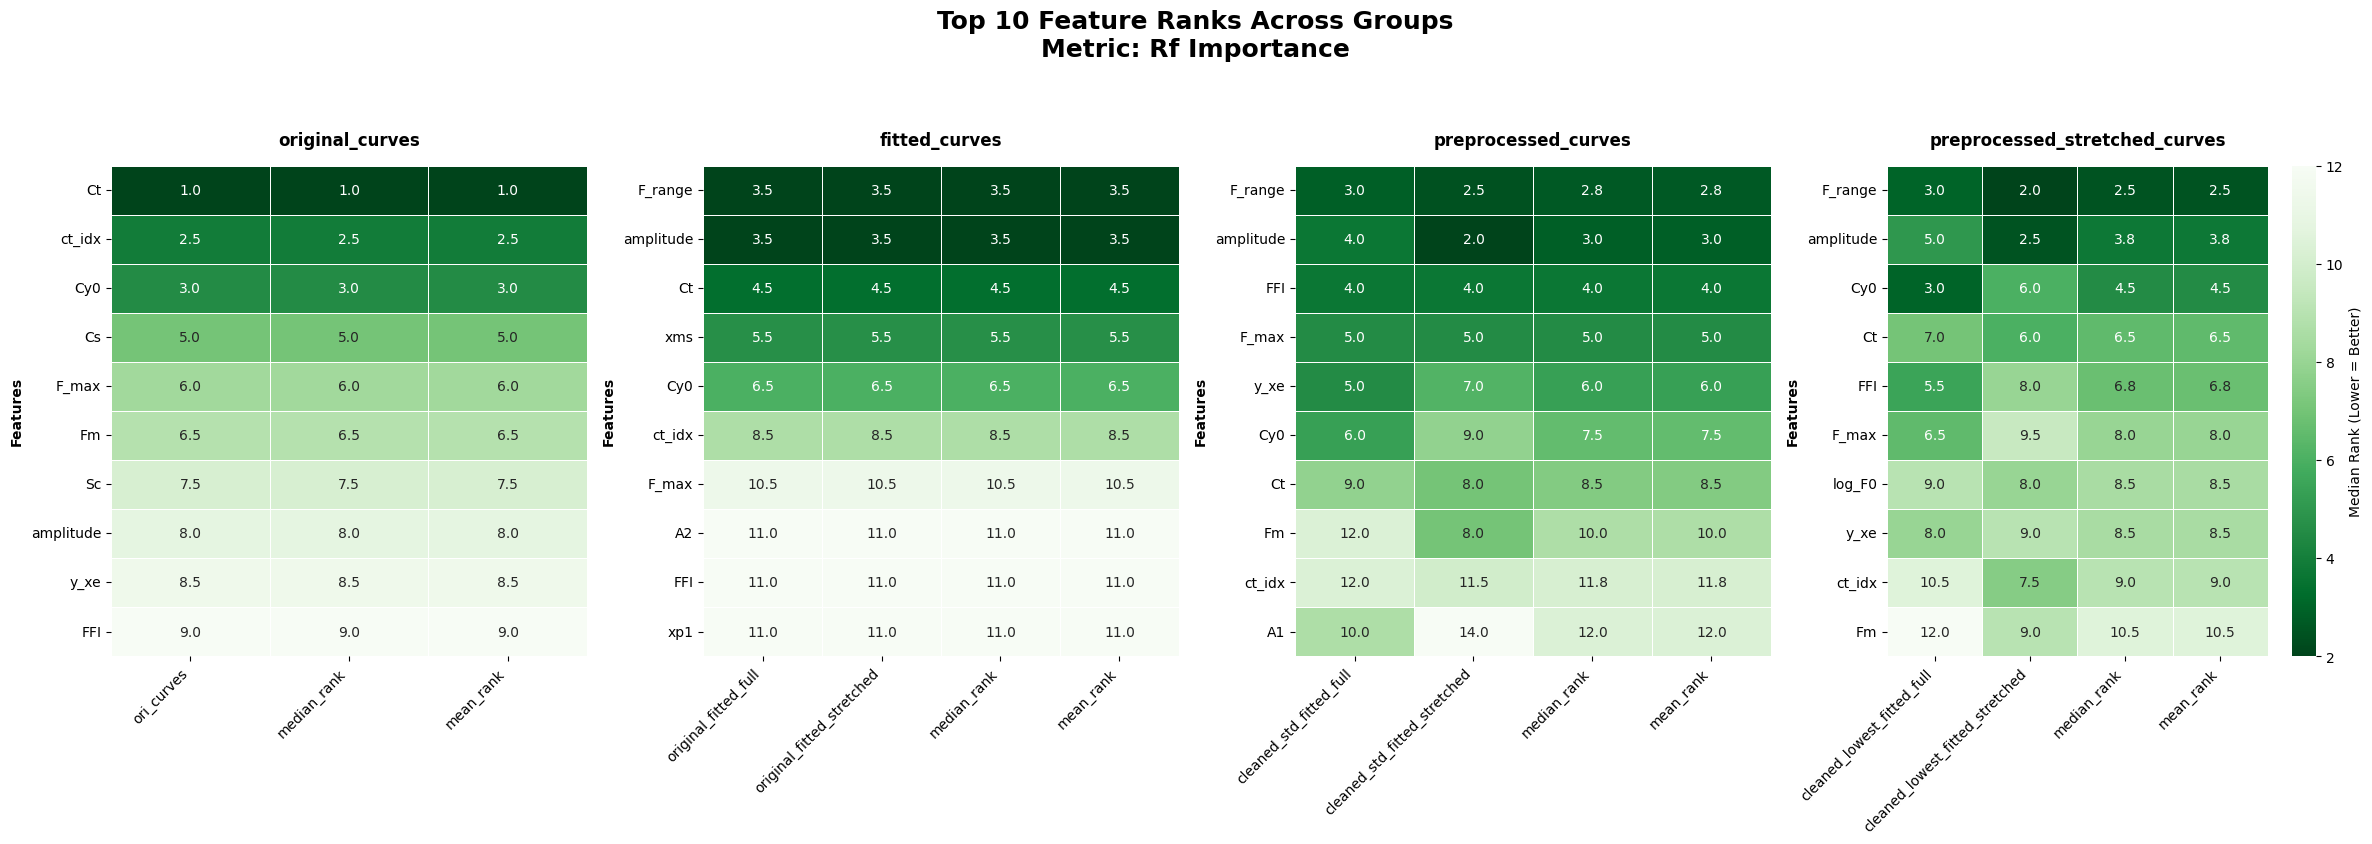

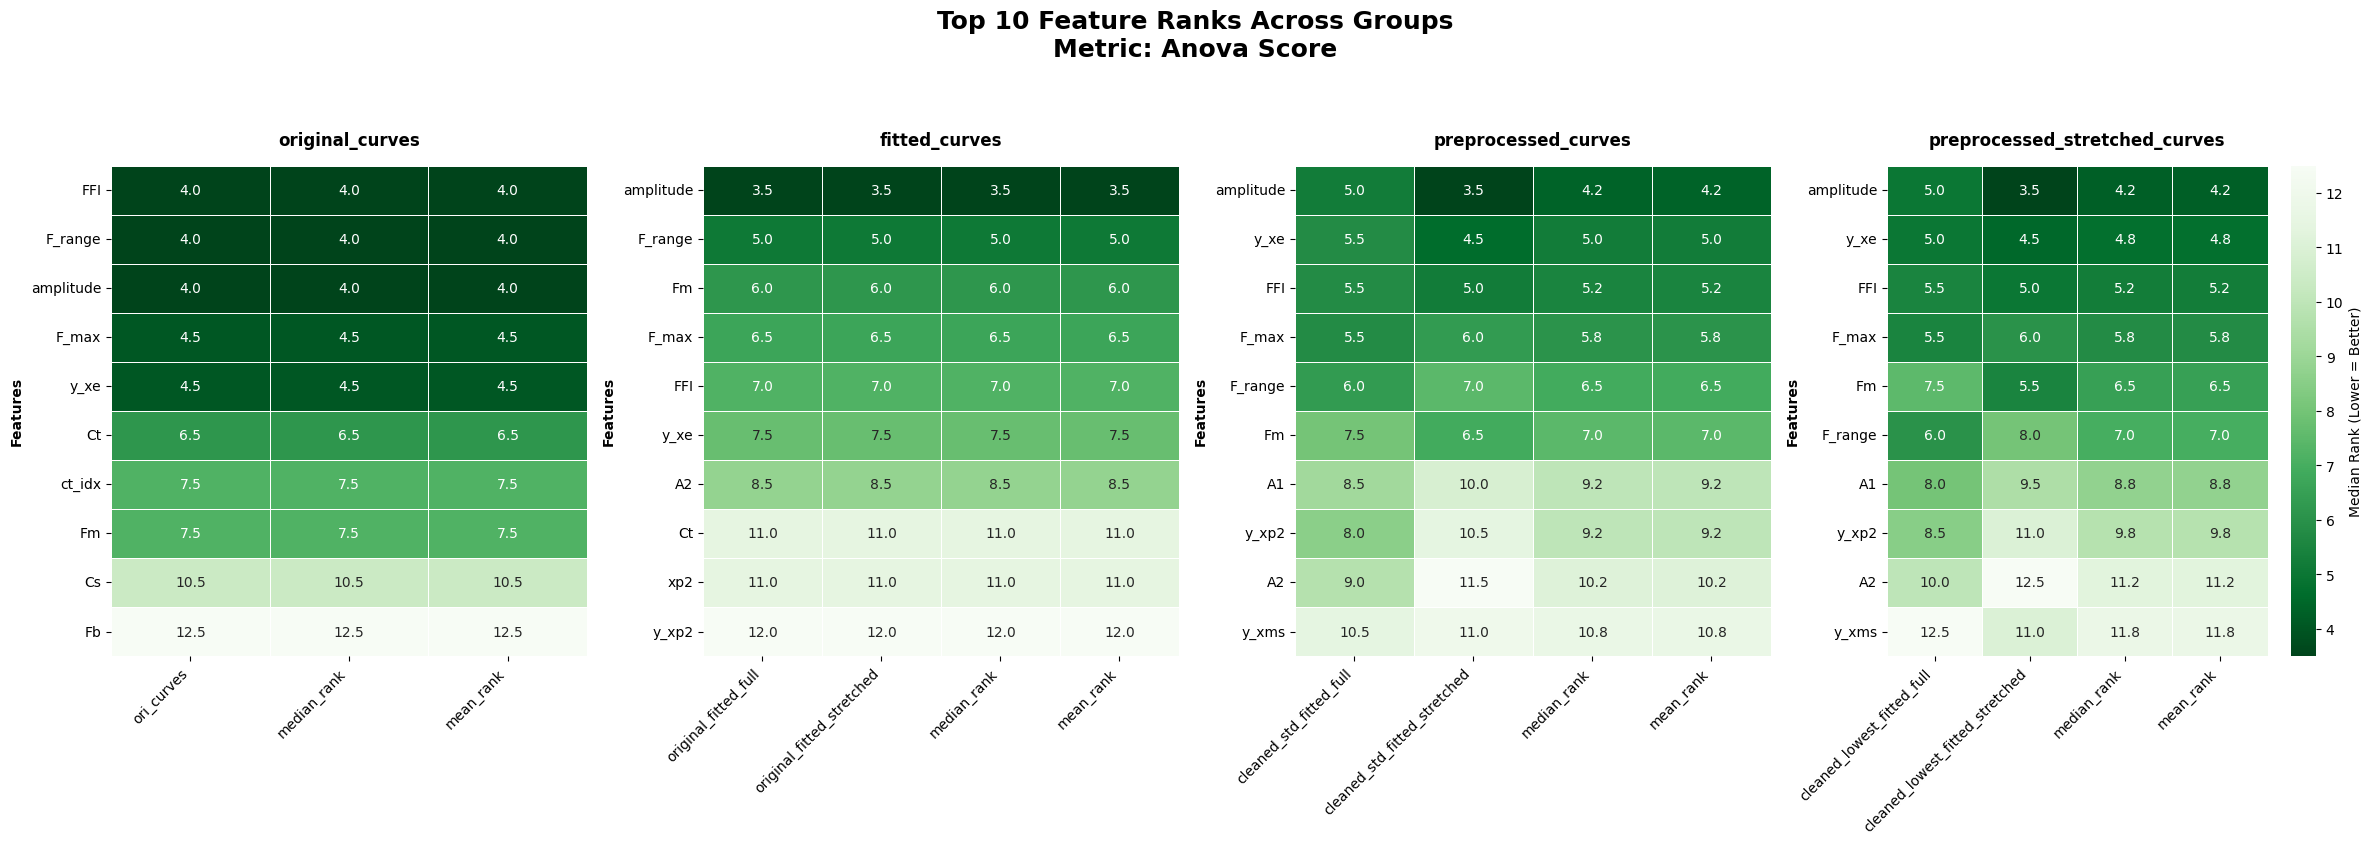

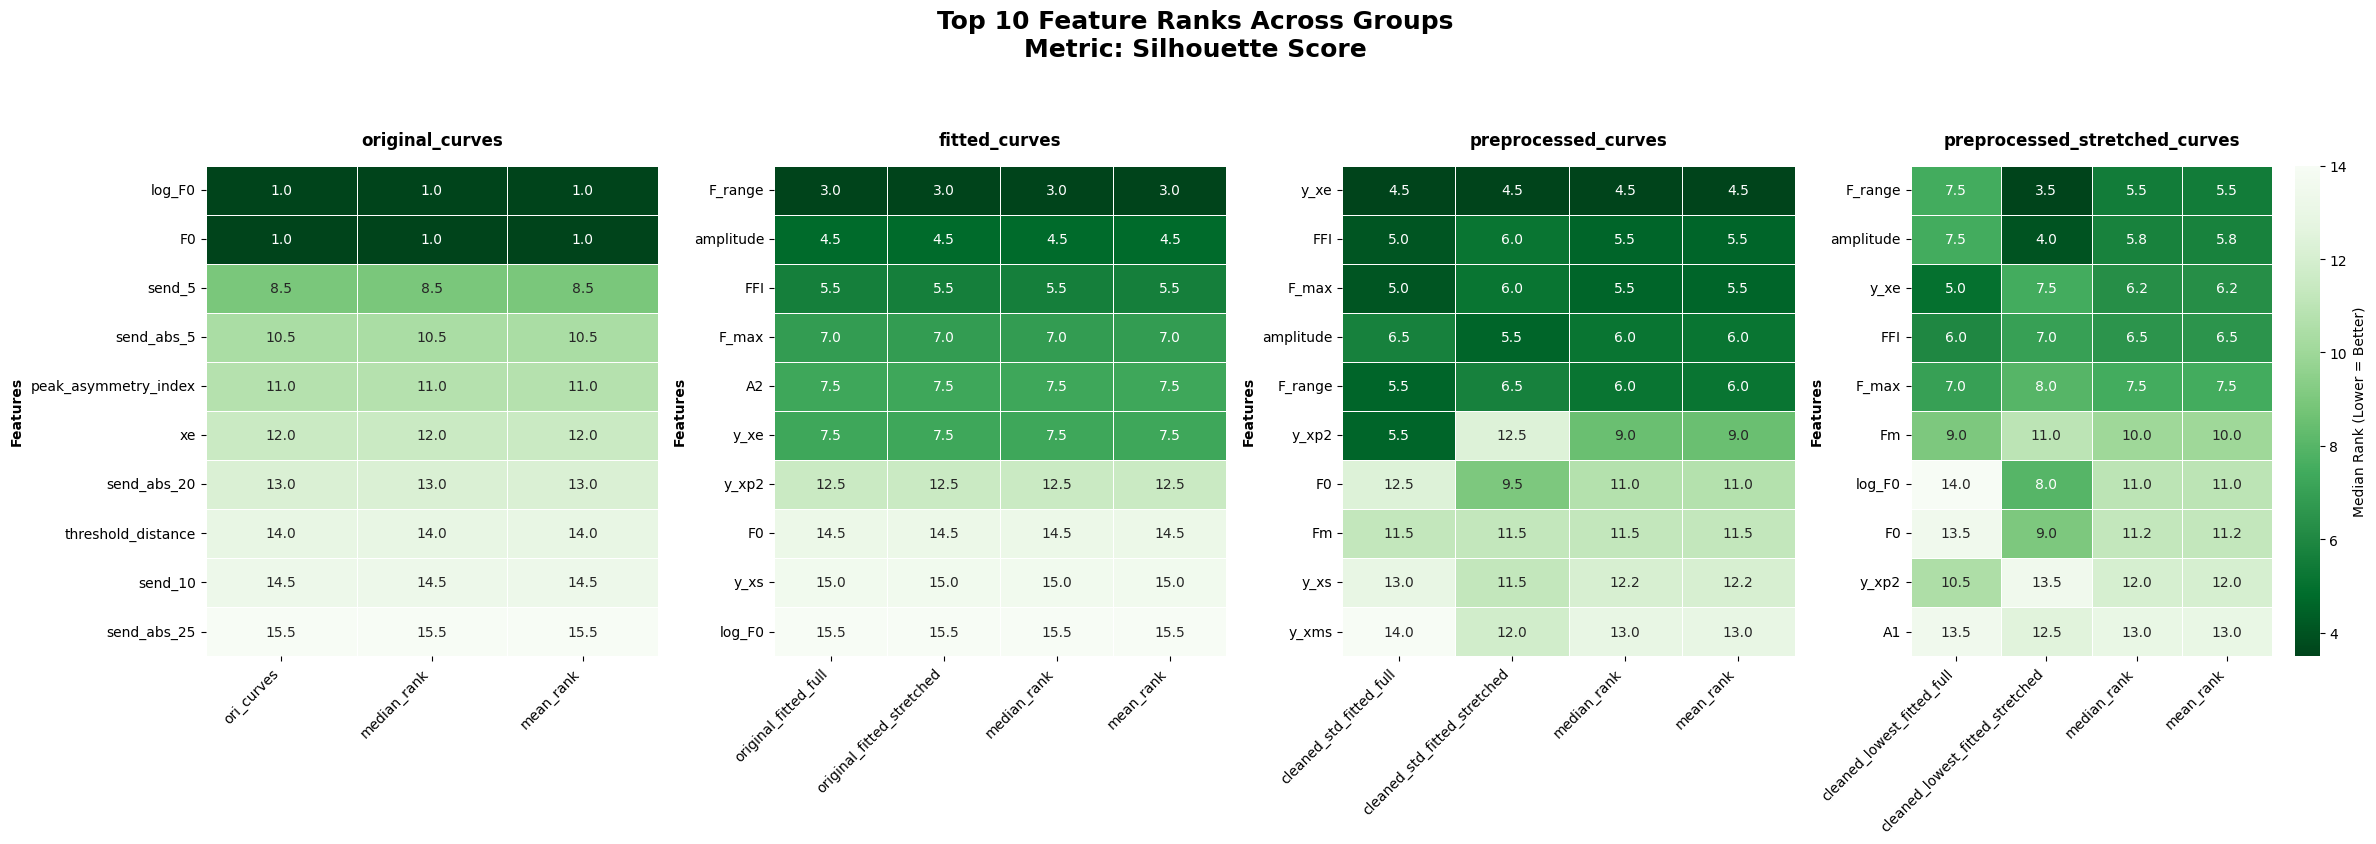

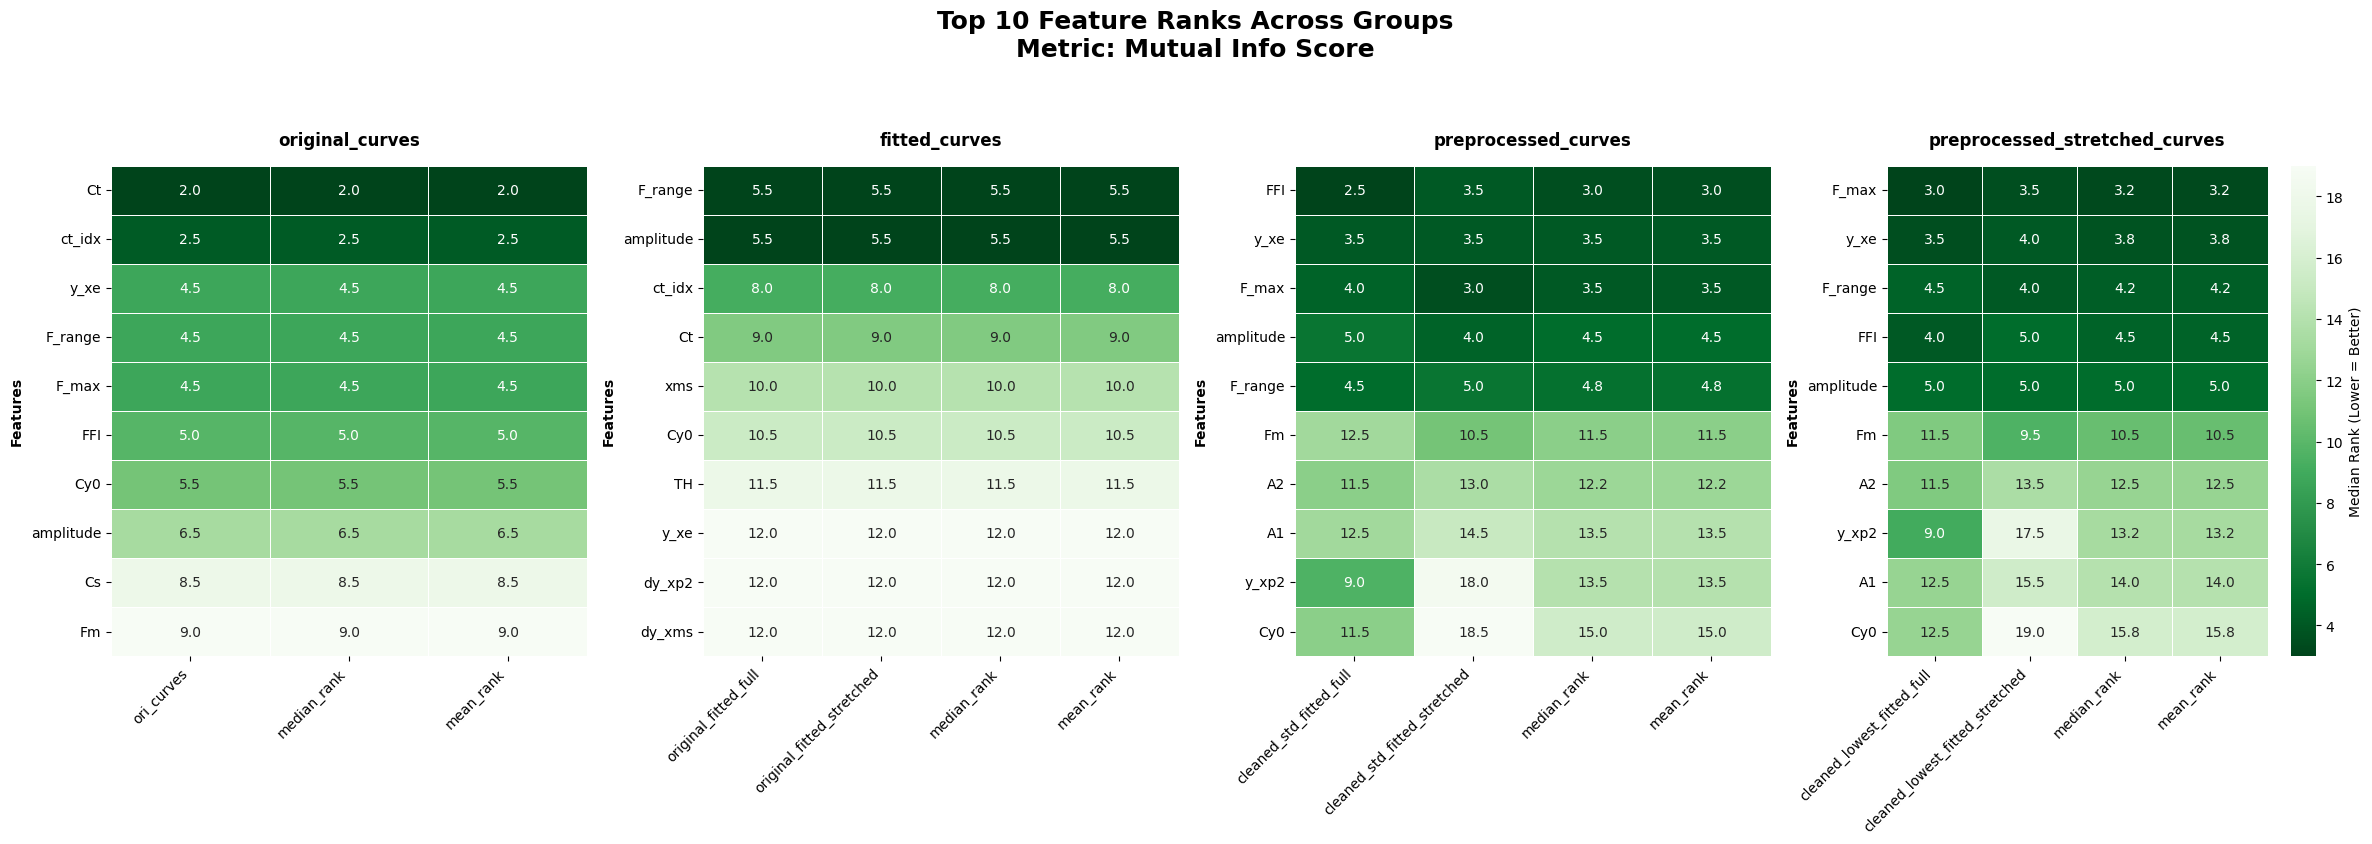

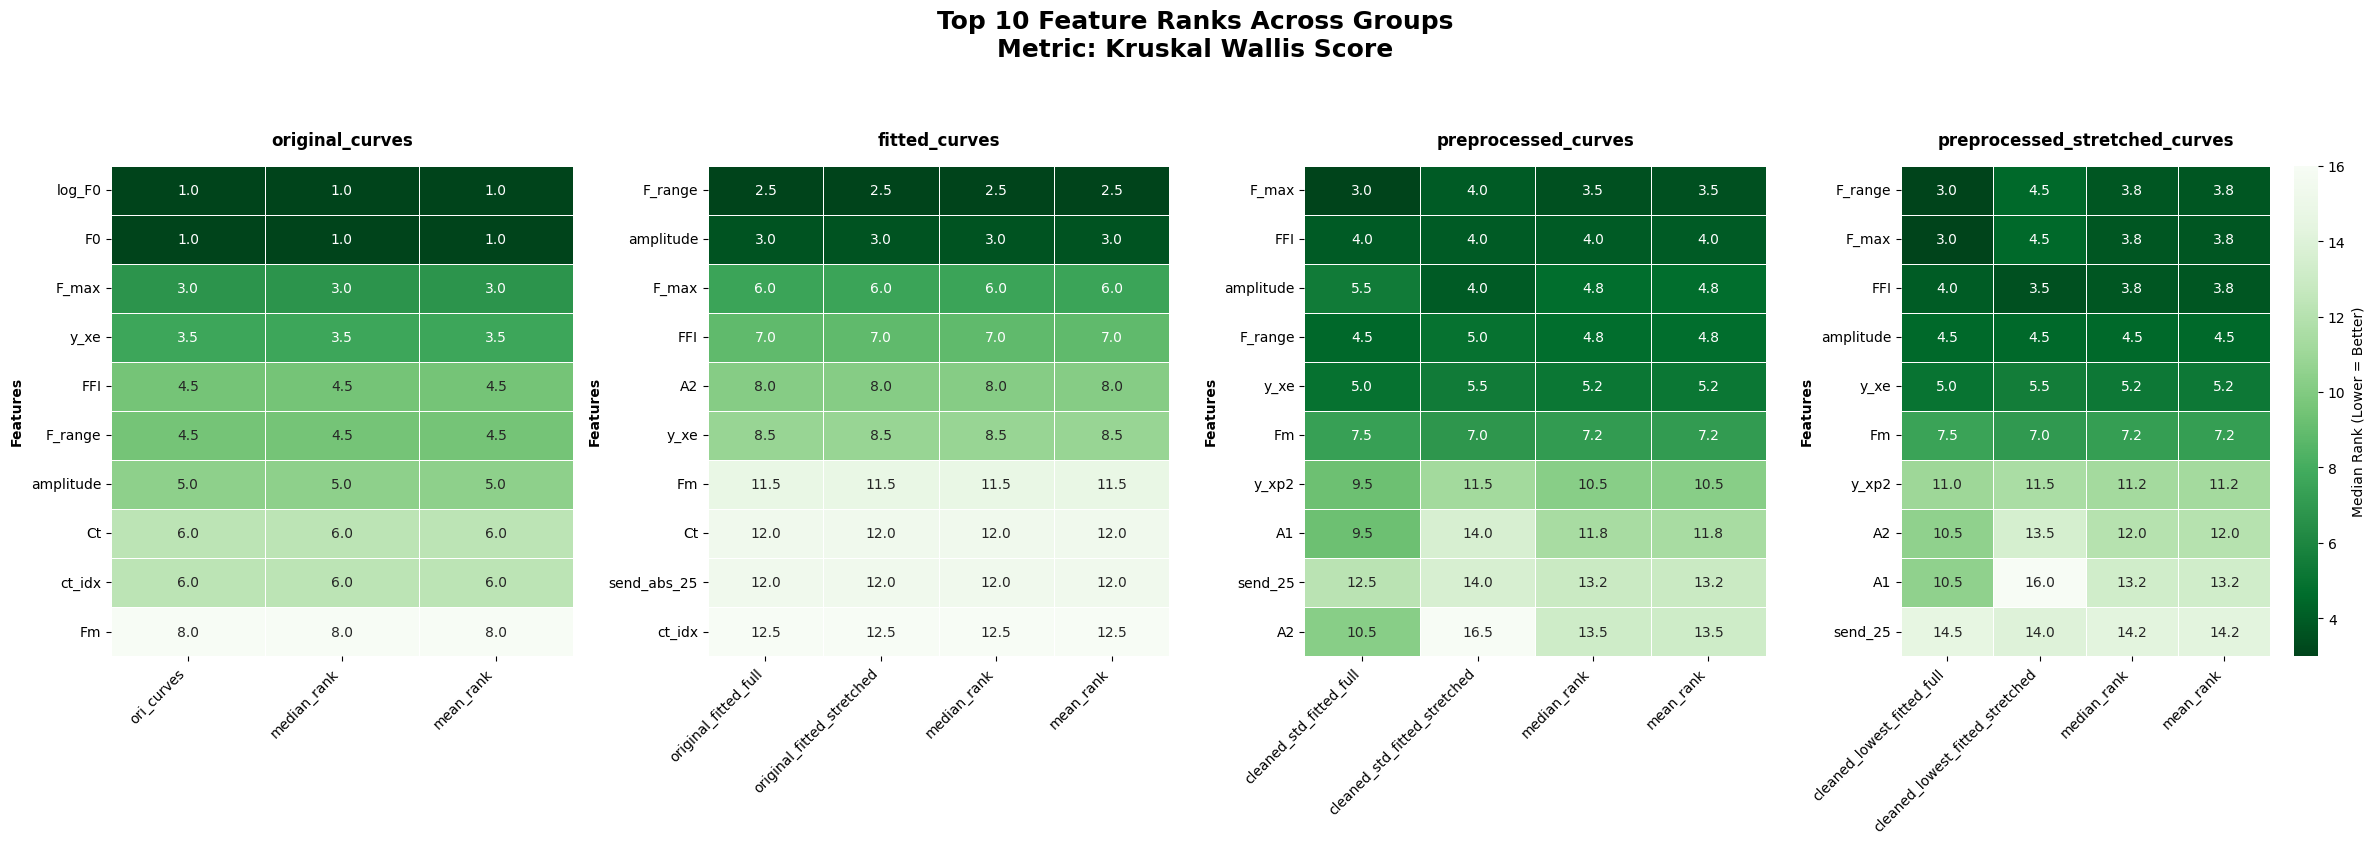

In [120]:
n_splits = len(curve_split)

for m in metrics:
    if m not in summary['curve_feature_median_rank']:
        print(f"Skipping {m} - not found in summary.")
        continue
        
    metric_df = summary['curve_feature_median_rank'][m]
    
    fig, axes = plt.subplots(nrows=1, ncols=n_splits, figsize=(6 * n_splits, 8))
    
    if n_splits == 1:
        axes = [axes]
        
    clean_metric_name = m.replace('_', ' ').title()
    fig.suptitle(f"Top 10 Feature Ranks Across Groups\nMetric: {clean_metric_name}", fontsize=18, fontweight='bold', y=1.05)
    
    for i, (k, v) in enumerate(curve_split.items()):
        split_columns = ['feature'] + v
        
        valid_cols = [c for c in split_columns if c in metric_df.columns]
        
        display_colorbar = (i == n_splits - 1)
        
        plot_feature_heatmap_on_ax(
            df=metric_df[valid_cols], 
            ax=axes[i], 
            title=f"{k}", 
            calculate_summary=True, 
            n_rank=10,
            show_cbar=display_colorbar
        )
        
    plt.tight_layout()
    plt.show()
    
    # Optional: Save the figure dynamically based on the metric name
    # save_path = f"feature_rank_heatmap_{m}.png"
    # plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
    
    plt.close(fig)

## Top Features Viz

In [124]:
def plot_feature_visuals(ax_dist, ax_scat, feature, feature_values, y_target, title_text):
    """
    Plots the normalized KDE distribution and the sorted scatter plot for a given feature.
    Automatically handles NaNs and infinite values.
    """
    # Clean Data (NaN / Inf Handling)
    valid_mask = ~np.isnan(feature_values) & ~np.isinf(feature_values)
    val_x = feature_values[valid_mask]
    val_y = y_target[valid_mask]
    
    if len(val_x) == 0:
        ax_dist.set_title(f"{title_text}\n(NO VALID DATA)")
        ax_scat.set_title(f"{title_text}\n(NO VALID DATA)")
        return
        
    df_plot = pd.DataFrame({feature: val_x, 'Target': val_y})
    
    # ---------------------------------------------------------
    # PLOT A: Histogram + KDE Distribution
    # ---------------------------------------------------------
    try:
        # Attempt to plot with KDE
        sns.histplot(
            data=df_plot, x=feature, hue='Target', bins=150, 
            kde=True, stat='density', palette='colorblind', 
            ax=ax_dist, linewidth=0, alpha=0.9, legend=True
        )
        
        # Force the KDE line to be black
        for line in ax_dist.lines:
            line.set_color('black')
            line.set_linewidth(1.5)
            
    except Exception:
        # Fallback if KDE fails due to LinAlgError (Zero Variance / Singular Matrix)
        sns.histplot(
            data=df_plot, x=feature, hue='Target', bins=150, 
            kde=False, stat='density', palette='colorblind', 
            ax=ax_dist, linewidth=0, alpha=0.9, legend=True
        )
        # Add a small note that KDE failed for transparency
        ax_dist.text(0.95, 0.95, 'KDE Failed', transform=ax_dist.transAxes, 
                     color='red', fontsize=8, ha='right', va='top')
        
    ax_dist.set_title(f"{title_text}", fontweight='bold', fontsize=11)
    ax_dist.set_xlabel(feature, fontsize=9)
    ax_dist.set_ylabel("Density", fontsize=9)
    
    # ---------------------------------------------------------
    # PLOT B: Sorted Scatter Plot (Event Number)
    # ---------------------------------------------------------
    sort_indices = np.argsort(val_y)
    sorted_y = val_y[sort_indices]
    sorted_feature = val_x[sort_indices]
    x_events = np.arange(len(sorted_feature))
    
    df_scatter = pd.DataFrame({
        'Event Number': x_events,
        feature: sorted_feature,
        'Target': sorted_y
    })
    
    sns.scatterplot(
        data=df_scatter, x='Event Number', y=feature, hue='Target', 
        palette='colorblind', edgecolor=None, s=25, 
        ax=ax_scat, legend=False
    )

    ax_scat.set_title(f"{title_text}", fontweight='bold', fontsize=11)
    ax_scat.set_xlabel("Event Number", fontsize=9)
    ax_scat.set_ylabel(f"{feature} Intensity", fontsize=9)

In [143]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------
# SAFE FEATURE HELPERS
# ----------------------------
def scalar_feat(val):
    if val is None:
        return np.nan
    if isinstance(val, (list, tuple, np.ndarray, pd.Series)):
        arr = np.asarray(val).flatten()
        if arr.size == 0:
            return np.nan
        for v in arr:
            if np.isfinite(v):
                return float(v)
        return np.nan
    return float(val) if np.isfinite(val) else np.nan

def make_feature_getter(sample_features):
    def F(name, default=np.nan):
        return scalar_feat(sample_features.get(name, default))
    return F

def get_idx(x_time, val):
    return np.argmin(np.abs(x_time - val))

# ----------------------------
# STYLE
# ----------------------------
def get_styles():
    return {
        "SCATTER_SIZE": 100,
        "EDGE": "black",
        "LW": 1.5,
        "SCATTER_ALPHA": 1.0,
        "Z": 10,
        "BASE_STYLE": {
            "F0":  dict(color="#00C853", marker="o"),
            "Fmax":dict(color="#2962FF", marker="^"),
            "Ct":  dict(color="#D500F9", marker="D"),
            "Cy0": dict(color="#FF1744", marker="X"),
            "xms": dict(color="#FF6D00", marker="s"),
            "xs":  dict(color="#00B0FF", marker="P"),
            "xe":  dict(color="#AA00FF", marker="v"),
            "xp1": dict(color="#00C853", marker="*"),
            "xp2": dict(color="#FF9100", marker="h"),
        },
        "D1_STYLE": {
            "xs":   dict(color="#00B0FF", marker="P"),
            "xe":   dict(color="#AA00FF", marker="v"),
            "xms":  dict(color="#FF6D00", marker="s"),
            "Send": dict(color="#D500F9", marker="X"),
        },
        "D2_STYLE": {
            "xp1": dict(color="#00C853", marker="*"),
            "xp2": dict(color="#FF1744", marker="X"),
        },
    }

# ----------------------------
# DATA PREP
# ----------------------------
def load_curve(dataset_metadata, curve_metadata, dataset, selected_name, selected_curve, sample_idx):
    dataset_idx = dataset_metadata["name"].index(selected_name)
    curve_idx = curve_metadata["name"].index(selected_curve)

    x_time = dataset_metadata["timestamps"][dataset_idx]
    y_ori = dataset["dataset_curves"][dataset_idx][curve_idx][sample_idx]
    sample_features = dataset["kinetic_features"][dataset_idx][curve_idx].iloc[sample_idx]

    dy_ori = np.gradient(y_ori, x_time)
    d2y_ori = np.gradient(dy_ori, x_time)

    return x_time, y_ori, dy_ori, d2y_ori, sample_features

def compute_limits(x_time, y_ori, dy_ori, d2y_ori, F):
    xmin = np.nanmin([F("Cy0"), F("Cy0_ori"), np.nanmin(x_time)])
    xmax = np.nanmax(x_time)
    ymin = min(0, np.nanmin(y_ori))
    ymax = np.nanmax(y_ori) * 1.05
    dymin, dymax = np.nanmin(dy_ori), np.nanmax(dy_ori)
    d2ymin, d2ymax = np.nanmin(d2y_ori), np.nanmax(d2y_ori)
    return xmin, xmax, ymin, ymax, dymin, dymax, d2ymin, d2ymax

# ----------------------------
# PLOT HELPERS
# ----------------------------
def scatter_point(ax, x, y, label, style, styles):
    ax.scatter(
        x, y, s=styles["SCATTER_SIZE"],
        edgecolor=styles["EDGE"], linewidth=styles["LW"],
        alpha=styles["SCATTER_ALPHA"], zorder=styles["Z"],
        label=label, **style
    )

def plot_base_curve(ax, x_time, y_ori, F, xmin, xmax, styles):
    ax.plot(x_time, y_ori, color="black", lw=2, label="F(t) Original Curve", alpha=0.75)
    ax.set_xlabel("Time / Cycle (x)")
    ax.set_ylabel("Fluorescence (F)")
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(min(0, np.nanmin(y_ori)), np.nanmax(y_ori) * 1.05)
    ax.grid(True, alpha=0.2)

    BS = styles["BASE_STYLE"]
    if np.isfinite(F("F0")):
        scatter_point(ax, x_time[0], y_ori[0], "F0", BS["F0"], styles)

    for key, label in [("xms", "xms"), ("xs", "xs"), ("xe", "xe"),
                       ("xp1", "xp1"), ("xp2", "xp2")]:
        if np.isfinite(F(key)) and xmin <= F(key) <= xmax:
            scatter_point(ax, F(key), y_ori[get_idx(x_time, F(key))], label, BS[key], styles)

    if np.isfinite(F("F_max_ori")):
        scatter_point(ax, x_time[np.argmax(y_ori)], np.max(y_ori), "Fmax_ori", BS["Fmax"], styles)

    if np.isfinite(F("Ct_ori")) and xmin <= F("Ct_ori") <= xmax:
        scatter_point(ax, F("Ct_ori"), y_ori[get_idx(x_time, F("Ct_ori"))], "Ct_ori (20%)", BS["Ct"], styles)

    if np.isfinite(F("Cy0_ori")) and xmin <= F("Cy0_ori") <= xmax:
        scatter_point(ax, F("Cy0_ori"), 0, "Cy0_ori", BS["Cy0"], styles)

    if np.isfinite(F("Ct_ori")) and np.isfinite(F("Cy0_ori")):
        ax.plot([F("Ct_ori"), F("Cy0_ori")],
                [y_ori[get_idx(x_time, F("Ct_ori"))], 0],
                ls="--", lw=1.2, color="magenta", label="Ct_ori → Cy0_ori")

    if np.isfinite(F("F_max")):
        scatter_point(ax, x_time[np.argmax(y_ori)], np.max(y_ori), "Fmax", BS["Fmax"], styles)

    if np.isfinite(F("Ct")) and xmin <= F("Ct") <= xmax:
        scatter_point(ax, F("Ct"), y_ori[get_idx(x_time, F("Ct"))], "Ct (20%)", BS["Ct"], styles)

    if np.isfinite(F("Cy0")) and xmin <= F("Cy0") <= xmax:
        scatter_point(ax, F("Cy0"), 0, "Cy0", BS["Cy0"], styles)

    if np.isfinite(F("Ct")) and np.isfinite(F("Cy0")):
        ax.plot([F("Ct"), F("Cy0")],
                [y_ori[get_idx(x_time, F("Ct"))], 0],
                ls="--", lw=1.2, color="magenta", label="Ct → Cy0")

    ax.legend(bbox_to_anchor=(1, 1), fontsize=8)
    ax.set_title("Original Curve", fontweight="bold")


def plot_d1(ax, x_time, dy_ori, F, xmin, xmax, dymin, dymax, styles):
    ax.plot(x_time, dy_ori, color="#1f77b4", lw=2, label="F'(t) First Derivative", alpha=0.75)
    ax.set_ylabel("Slope (dy/dx)")
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(dymin, dymax)
    ax.grid(True, alpha=0.2)

    D1 = styles["D1_STYLE"]
    if np.isfinite(F("TH")):
        ax.axhline(F("TH"), color="gray", ls="--", lw=1, label="TH (10% Max Slope)")

    for key in ["xs", "xe", "xms"]:
        if np.isfinite(F(key)):
            scatter_point(ax, F(key), dy_ori[get_idx(x_time, F(key))], key, D1[key], styles)

    if np.isfinite(F("A1")) and np.isfinite(F("xs")) and np.isfinite(F("xms")):
        i1, i2 = get_idx(x_time, F("xs")), get_idx(x_time, F("xms"))
        ax.fill_between(x_time[i1:i2+1], 0, dy_ori[i1:i2+1], color="green", alpha=0.25, label="A1")

    if np.isfinite(F("A2")) and np.isfinite(F("xms")) and np.isfinite(F("xe")):
        i1, i2 = get_idx(x_time, F("xms")), get_idx(x_time, F("xe"))
        ax.fill_between(x_time[i1:i2+1], 0, dy_ori[i1:i2+1], color="orange", alpha=0.25, label="A2")

    if np.isfinite(F("xs")):
        ax.axvline(F("xs"), color="blue", ls=":", lw=1)
    if np.isfinite(F("xe")):
        ax.axvline(F("xe"), color="blue", ls=":", lw=1)

    if np.isfinite(F("threshold_distance")) and np.isfinite(F("xs")) and np.isfinite(F("xe")):
        y_h = np.nanmax(dy_ori) * 0.2
        ax.annotate("", xy=(F("xs"), y_h), xytext=(F("xe"), y_h),
                    arrowprops=dict(arrowstyle="<->", color="black"))
        ax.text((F("xs")+F("xe"))/2, y_h, "threshold_distance", fontsize=8,
                bbox=dict(boxstyle="round", fc="white", alpha=0.8))

    if np.isfinite(F("Send")):
        scatter_point(ax, x_time[-1], dy_ori[-1], "Send (Last 5 pts)", D1["Send"], styles)

    ax.legend(bbox_to_anchor=(1, 1), fontsize=8)
    ax.set_title("1st Derivative", fontweight="bold")


def plot_d2(ax, x_time, d2y_ori, F, xmin, xmax, d2ymin, d2ymax, styles):
    ax.plot(x_time, d2y_ori, color="#2ca02c", lw=2, label="F''(t) Second Derivative", alpha=0.75)
    ax.set_xlabel("Time / Cycle (x)")
    ax.set_ylabel("Acceleration (d2y/dx2)")
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(d2ymin, d2ymax)
    ax.grid(True, alpha=0.2)

    D2 = styles["D2_STYLE"]
    if np.isfinite(F("xp1")):
        scatter_point(ax, F("xp1"), d2y_ori[get_idx(x_time, F("xp1"))], "xp1 (Positive Peak)", D2["xp1"], styles)
    if np.isfinite(F("xp2")):
        scatter_point(ax, F("xp2"), d2y_ori[get_idx(x_time, F("xp2"))], "xp2 (Negative Peak)", D2["xp2"], styles)

    if np.isfinite(F("xp1")):
        ax.axvline(F("xp1"), color="blue", ls=":", lw=1)
    if np.isfinite(F("xp2")):
        ax.axvline(F("xp2"), color="blue", ls=":", lw=1)
        
    if np.isfinite(F("peak_shifting_distance")) and np.isfinite(F("xp1")) and np.isfinite(F("xp2")):
        ax.annotate("", xy=(F("xp1"), 0), xytext=(F("xp2"), 0),
                    arrowprops=dict(arrowstyle="<->", color="black"))
        ax.text((F("xp1")+F("xp2"))/2, 0, "peak_shifting_distance", fontsize=8,
                bbox=dict(boxstyle="round", fc="white", alpha=0.8))

    ax.legend(bbox_to_anchor=(1, 1), fontsize=8)
    ax.set_title("2nd Derivative", fontweight="bold")


# ----------------------------
# MAIN DRIVER
# ----------------------------
def plot_kinetic_mapping(dataset_metadata, curve_metadata, dataset,
                         selected_name, selected_curve, sample_idx):
    x_time, y_ori, dy_ori, d2y_ori, sample_features = load_curve(
        dataset_metadata, curve_metadata, dataset,
        selected_name, selected_curve, sample_idx
    )

    F = make_feature_getter(sample_features)
    xmin, xmax, ymin, ymax, dymin, dymax, d2ymin, d2ymax = compute_limits(
        x_time, y_ori, dy_ori, d2y_ori, F
    )
    styles = get_styles()

    fig = plt.figure(figsize=(18, 9))
    gs = fig.add_gridspec(2, 2, width_ratios=[1.1, 1], height_ratios=[1, 1],
                          wspace=0.5, hspace=0.3)

    ax_base = fig.add_subplot(gs[:, 0])
    ax_d1 = fig.add_subplot(gs[0, 1])
    ax_d2 = fig.add_subplot(gs[1, 1])

    fig.suptitle(f"Kinetic Curve Feature Extraction Mapping\n{selected_name}\n{selected_curve} - curve_id={sample_idx}", fontsize=16, fontweight="bold")

    plot_base_curve(ax_base, x_time, y_ori, F, xmin, xmax, styles)
    plot_d1(ax_d1, x_time, dy_ori, F, xmin, xmax, dymin, dymax, styles)
    plot_d2(ax_d2, x_time, d2y_ori, F, xmin, xmax, d2ymin, d2ymax, styles)

    plt.show()

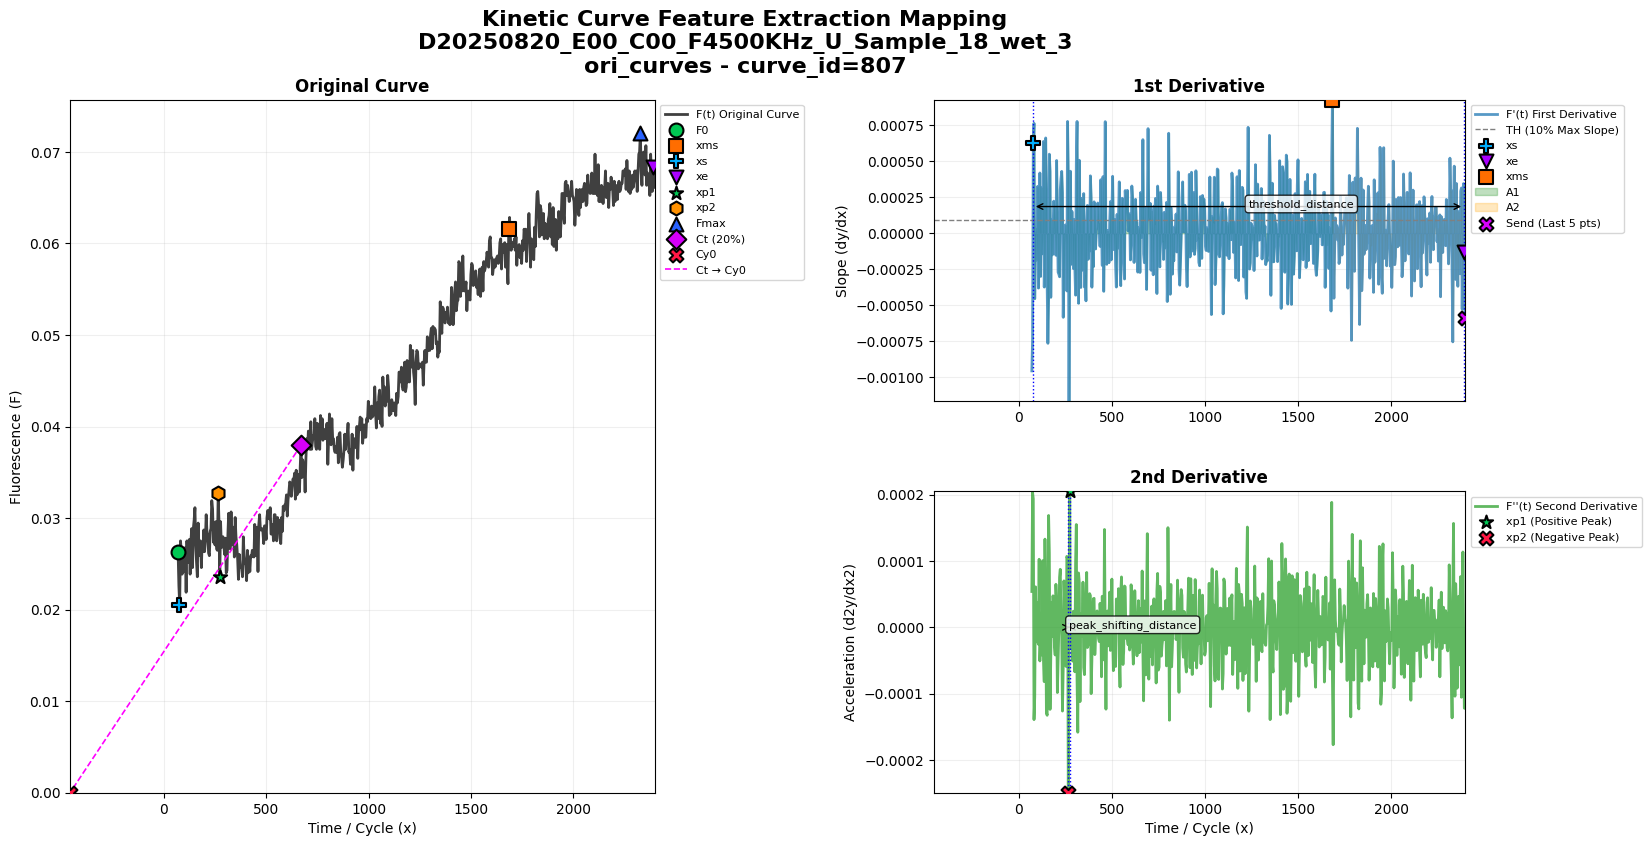

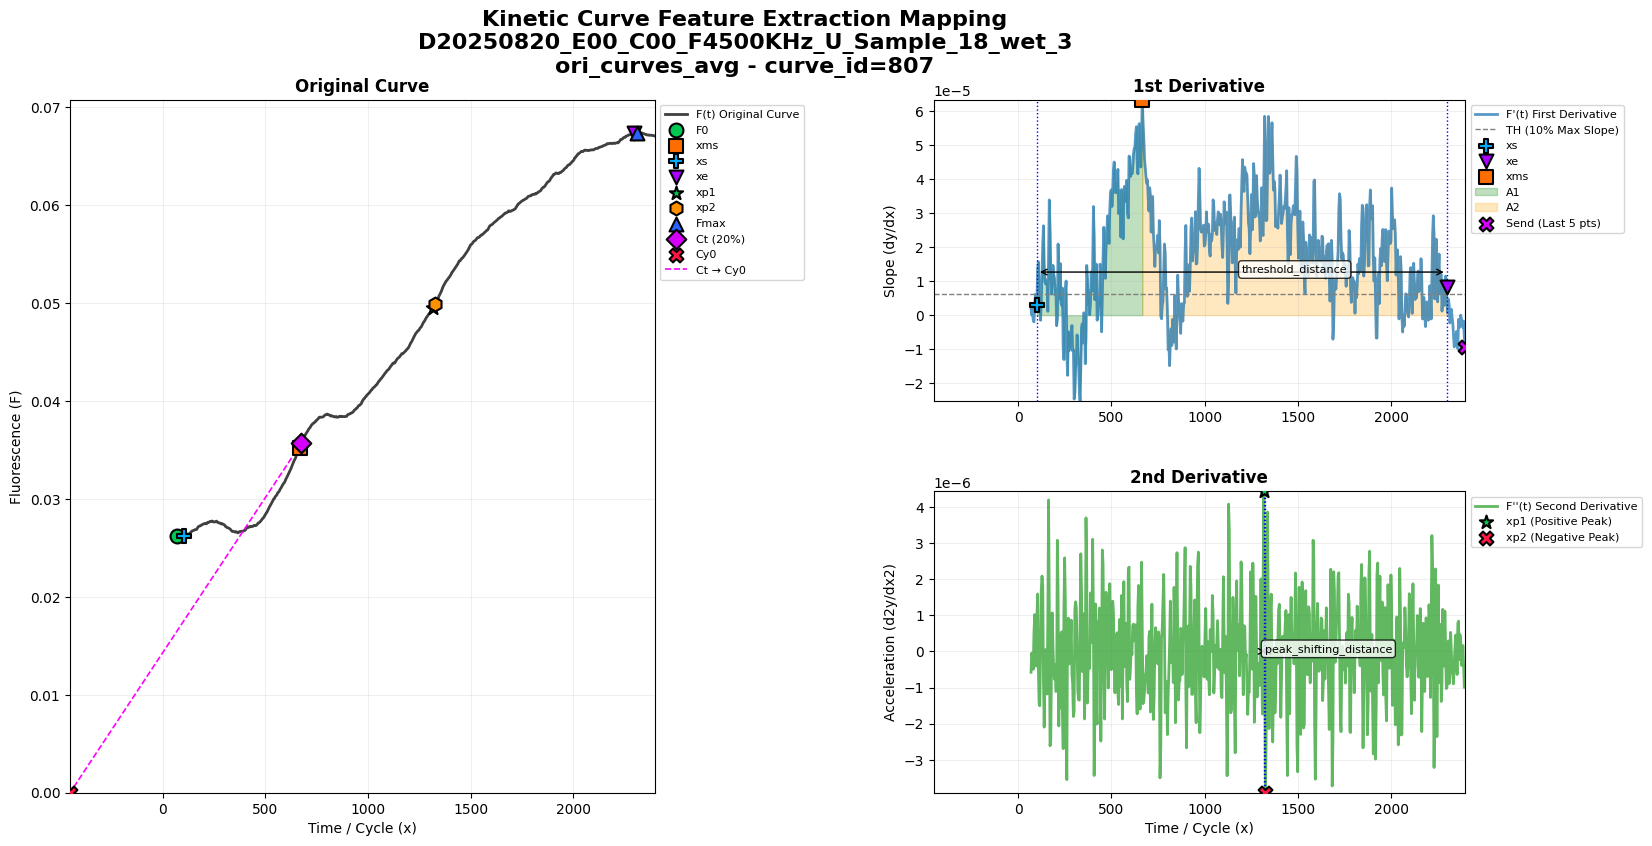

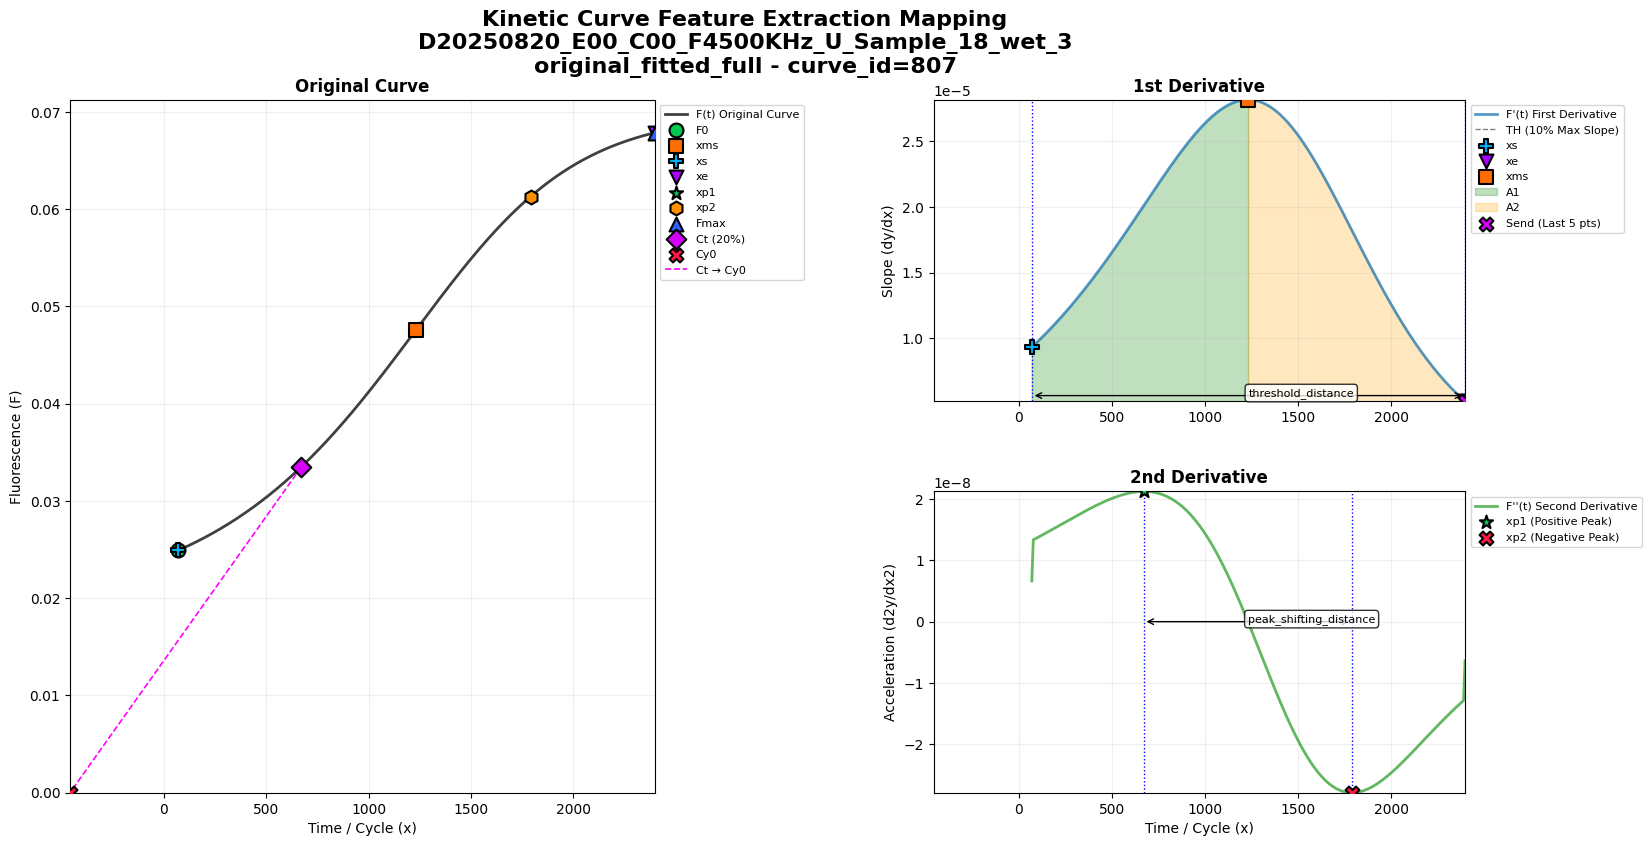

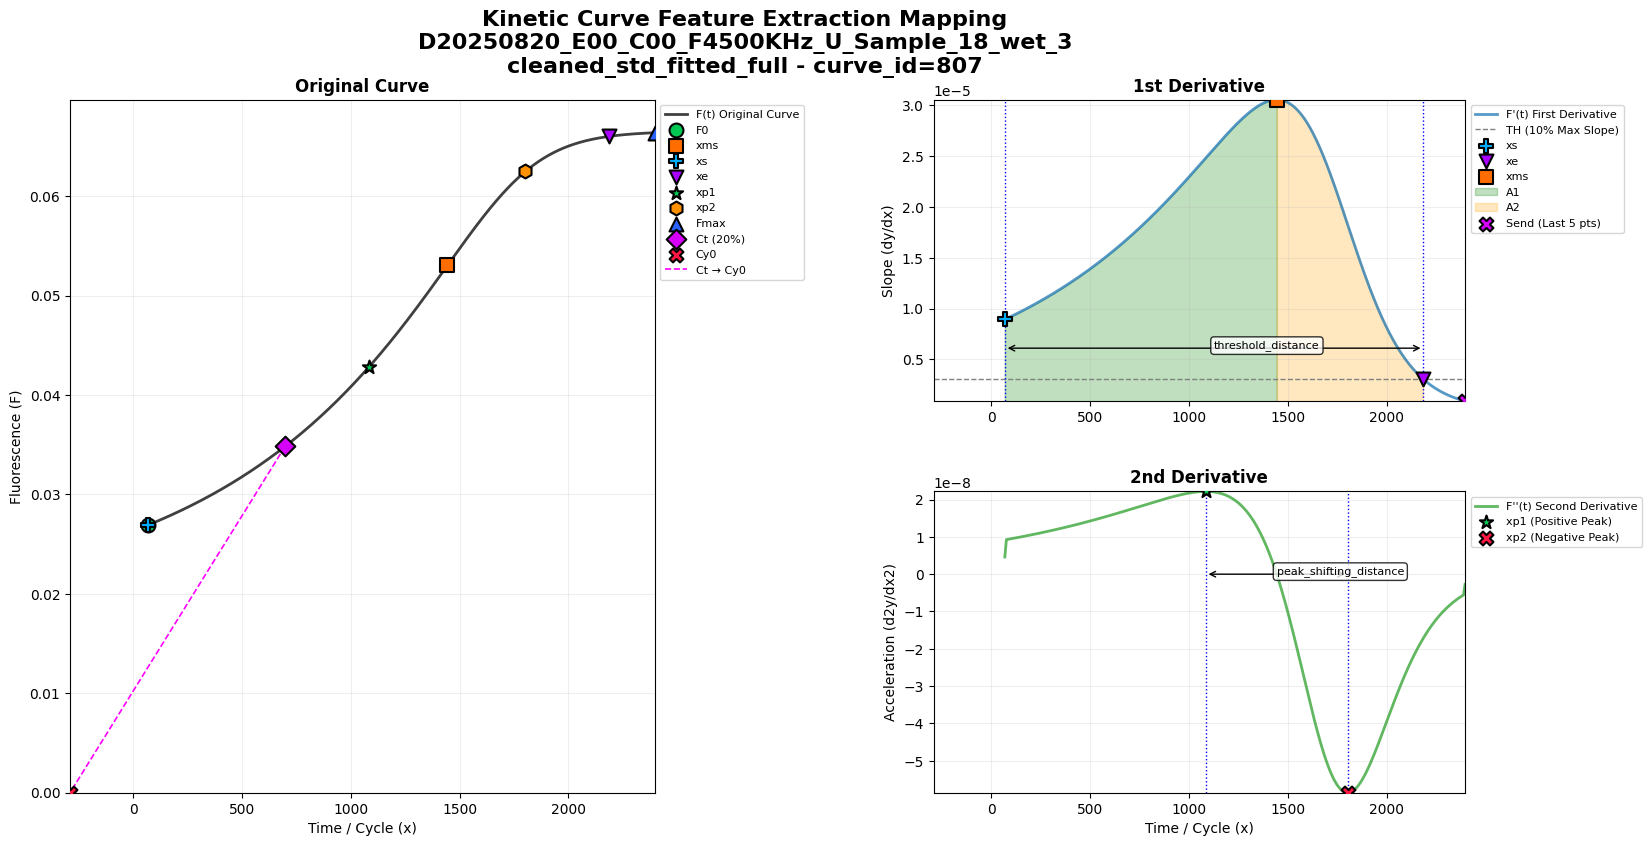

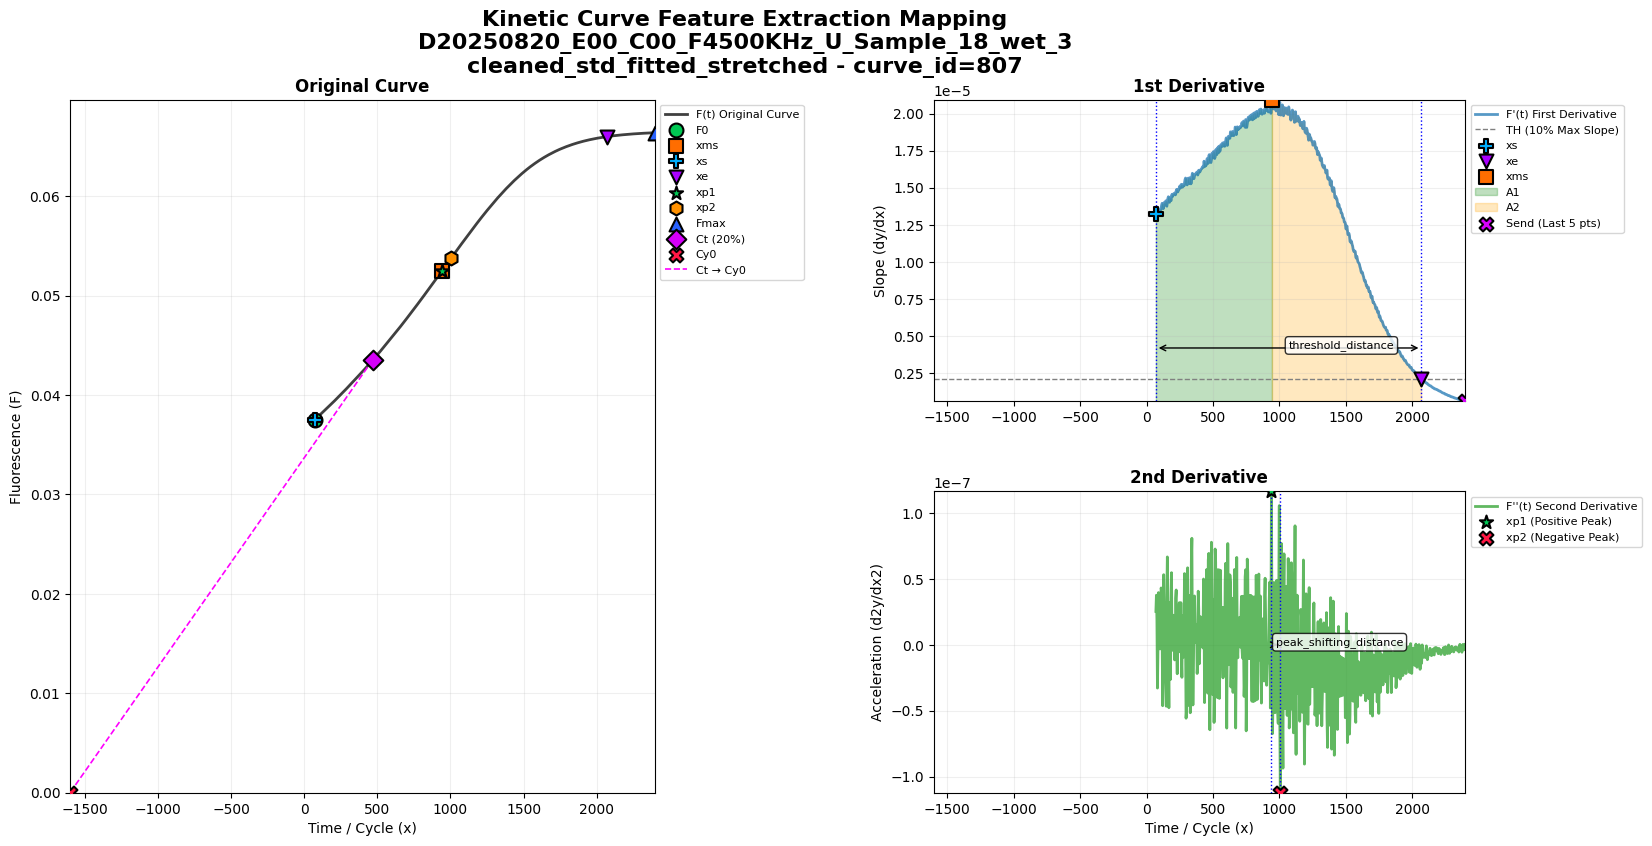

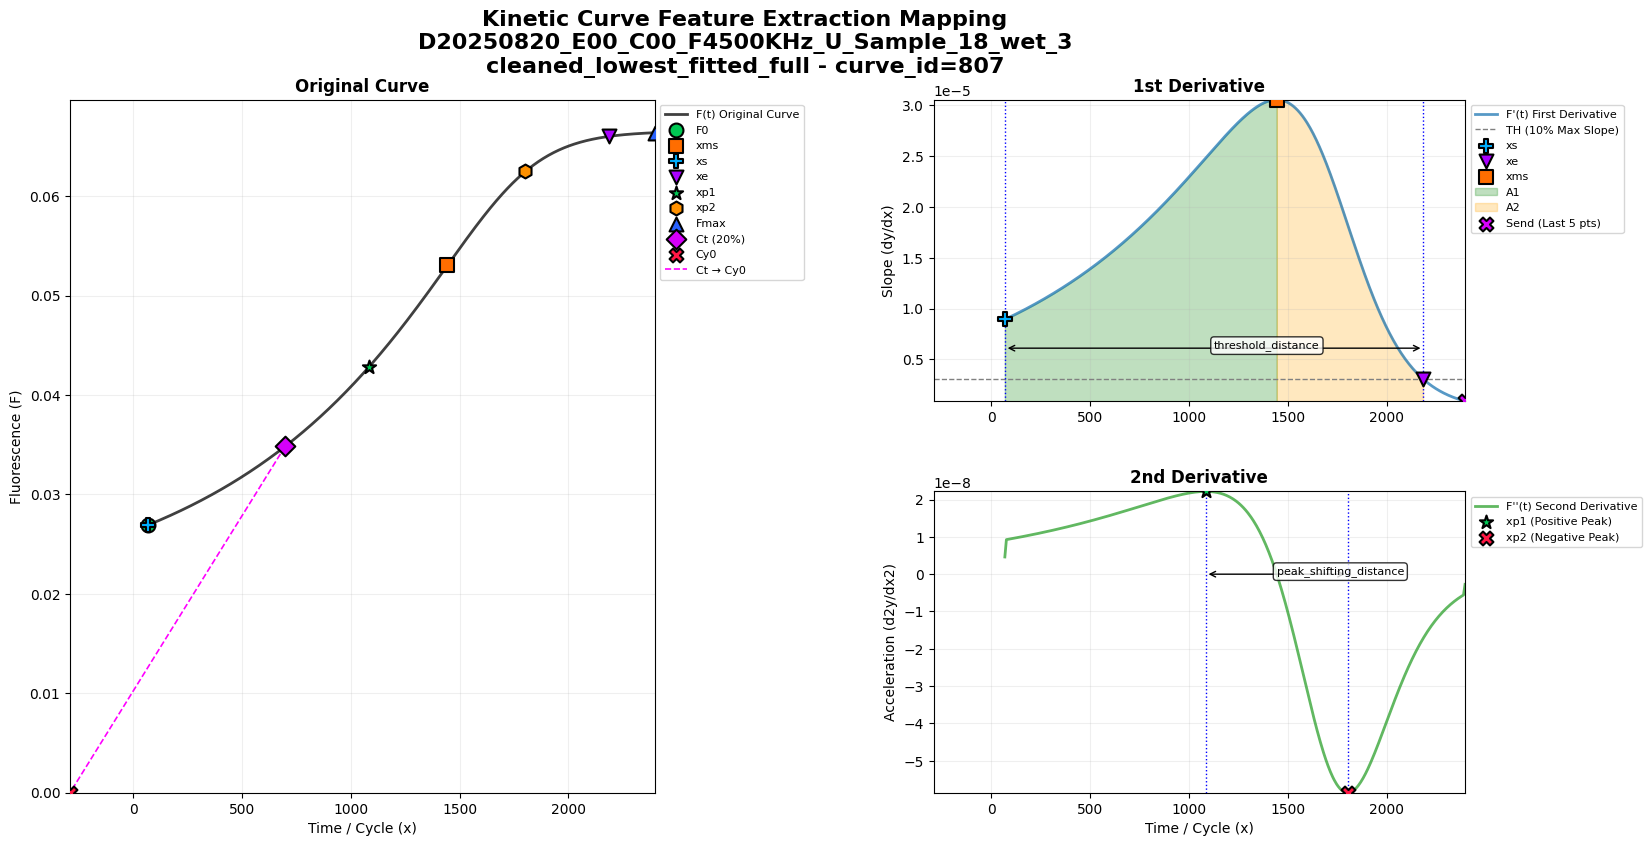

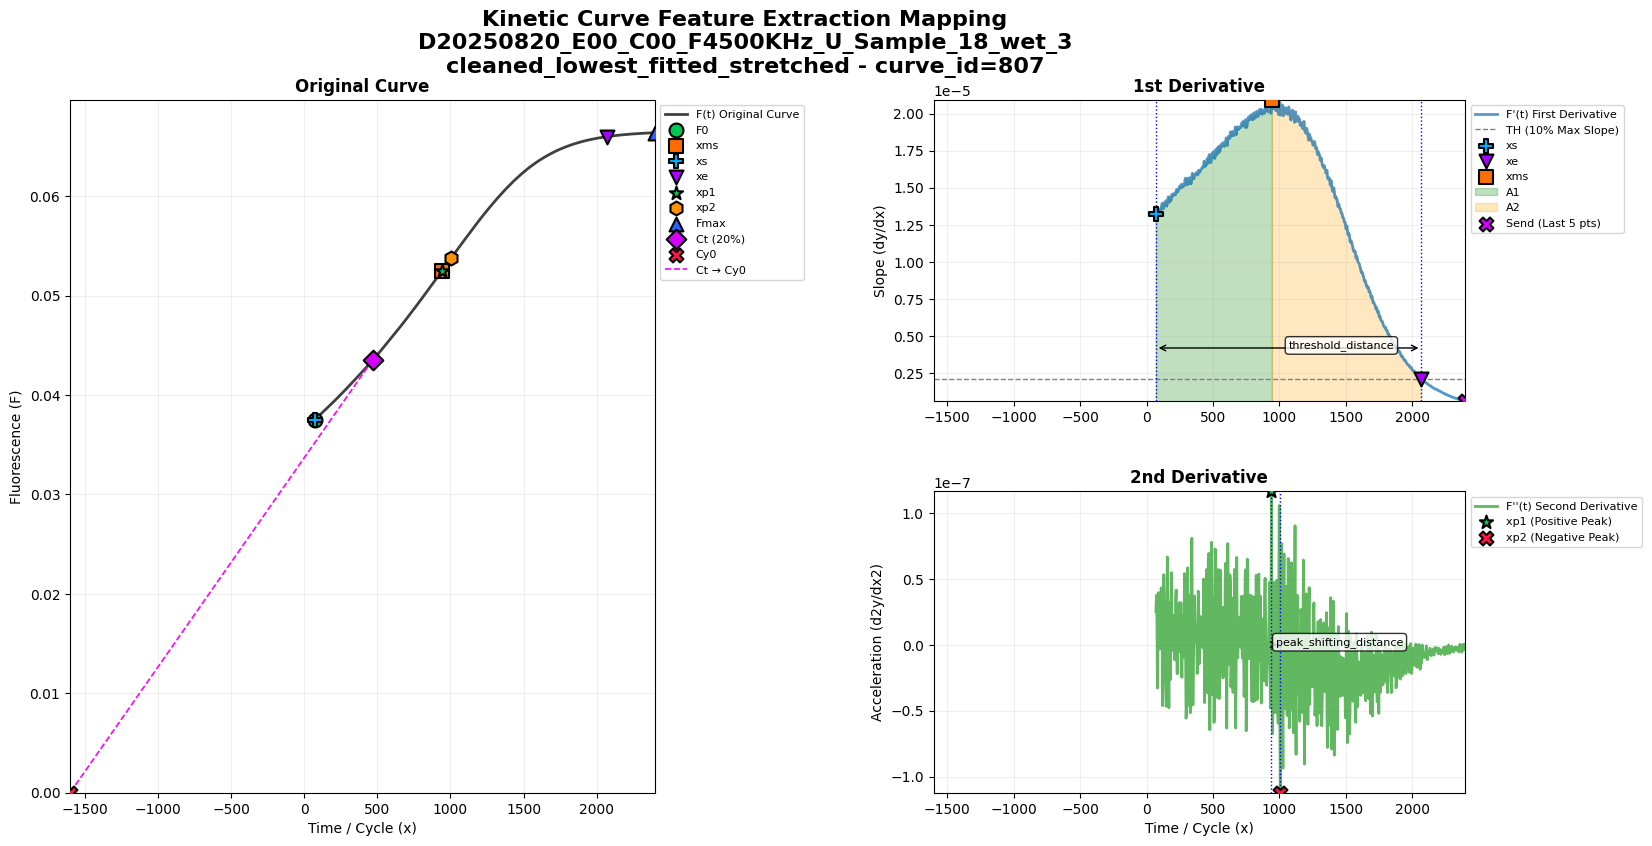

In [147]:
SELECTED_DATASET_NAME = "D20250820_E00_C00_F4500KHz_U_Sample_18_wet_3"
SELECTED_CURVE_TYPE = "ori_curves"
CURVE_SAMPLE_IDX = 807

SELECTED_CURVE_TYPES = [cname for cname in curve_metadata['name'] if cname != 'original_fitted_stretched' ]

for cname in SELECTED_CURVE_TYPES:
    plot_kinetic_mapping(dataset_metadata, curve_metadata, dataset,
                         SELECTED_DATASET_NAME, cname, CURVE_SAMPLE_IDX)

In [127]:
curve_metadata["name"]

['ori_curves',
 'ori_curves_avg',
 'original_fitted_full',
 'original_fitted_stretched',
 'cleaned_std_fitted_full',
 'cleaned_std_fitted_stretched',
 'cleaned_lowest_fitted_full',
 'cleaned_lowest_fitted_stretched']

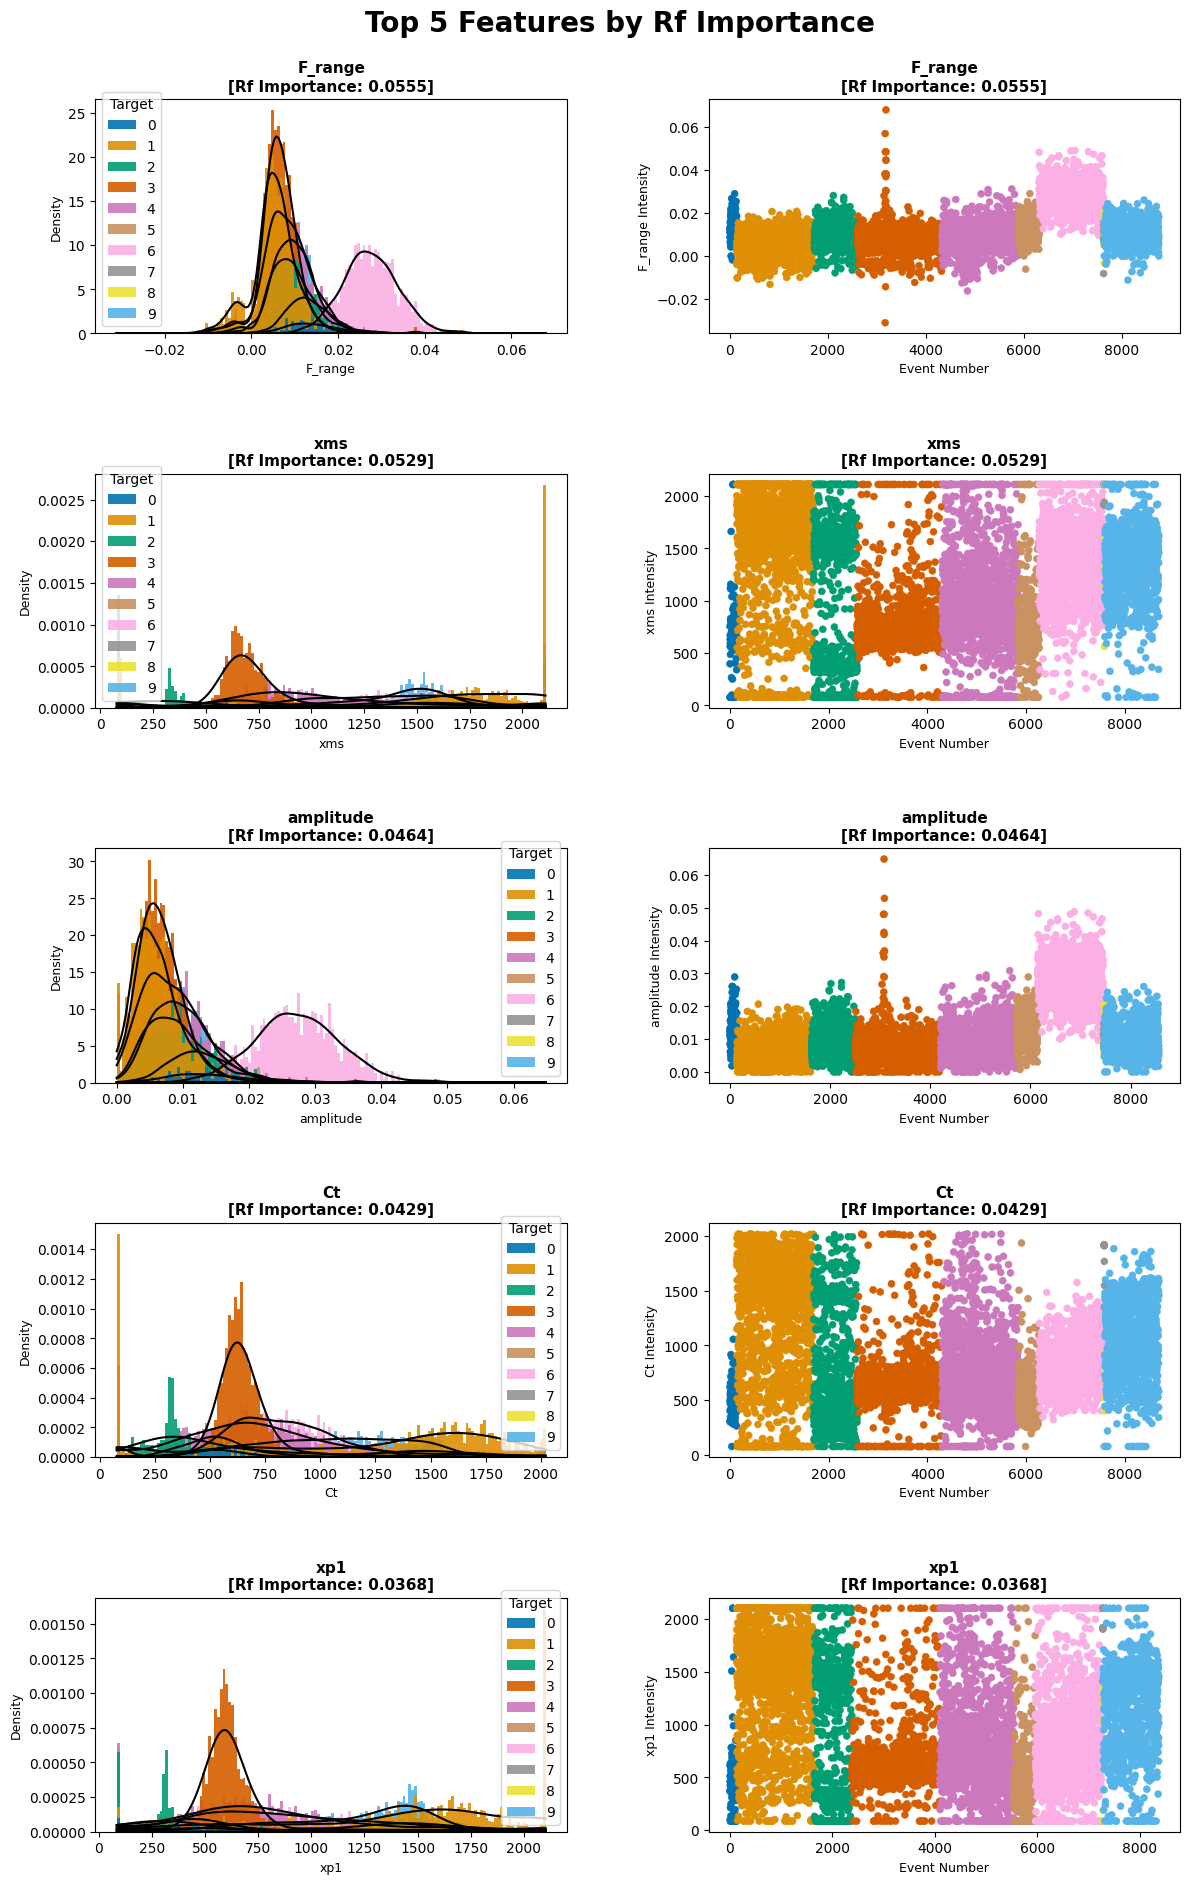

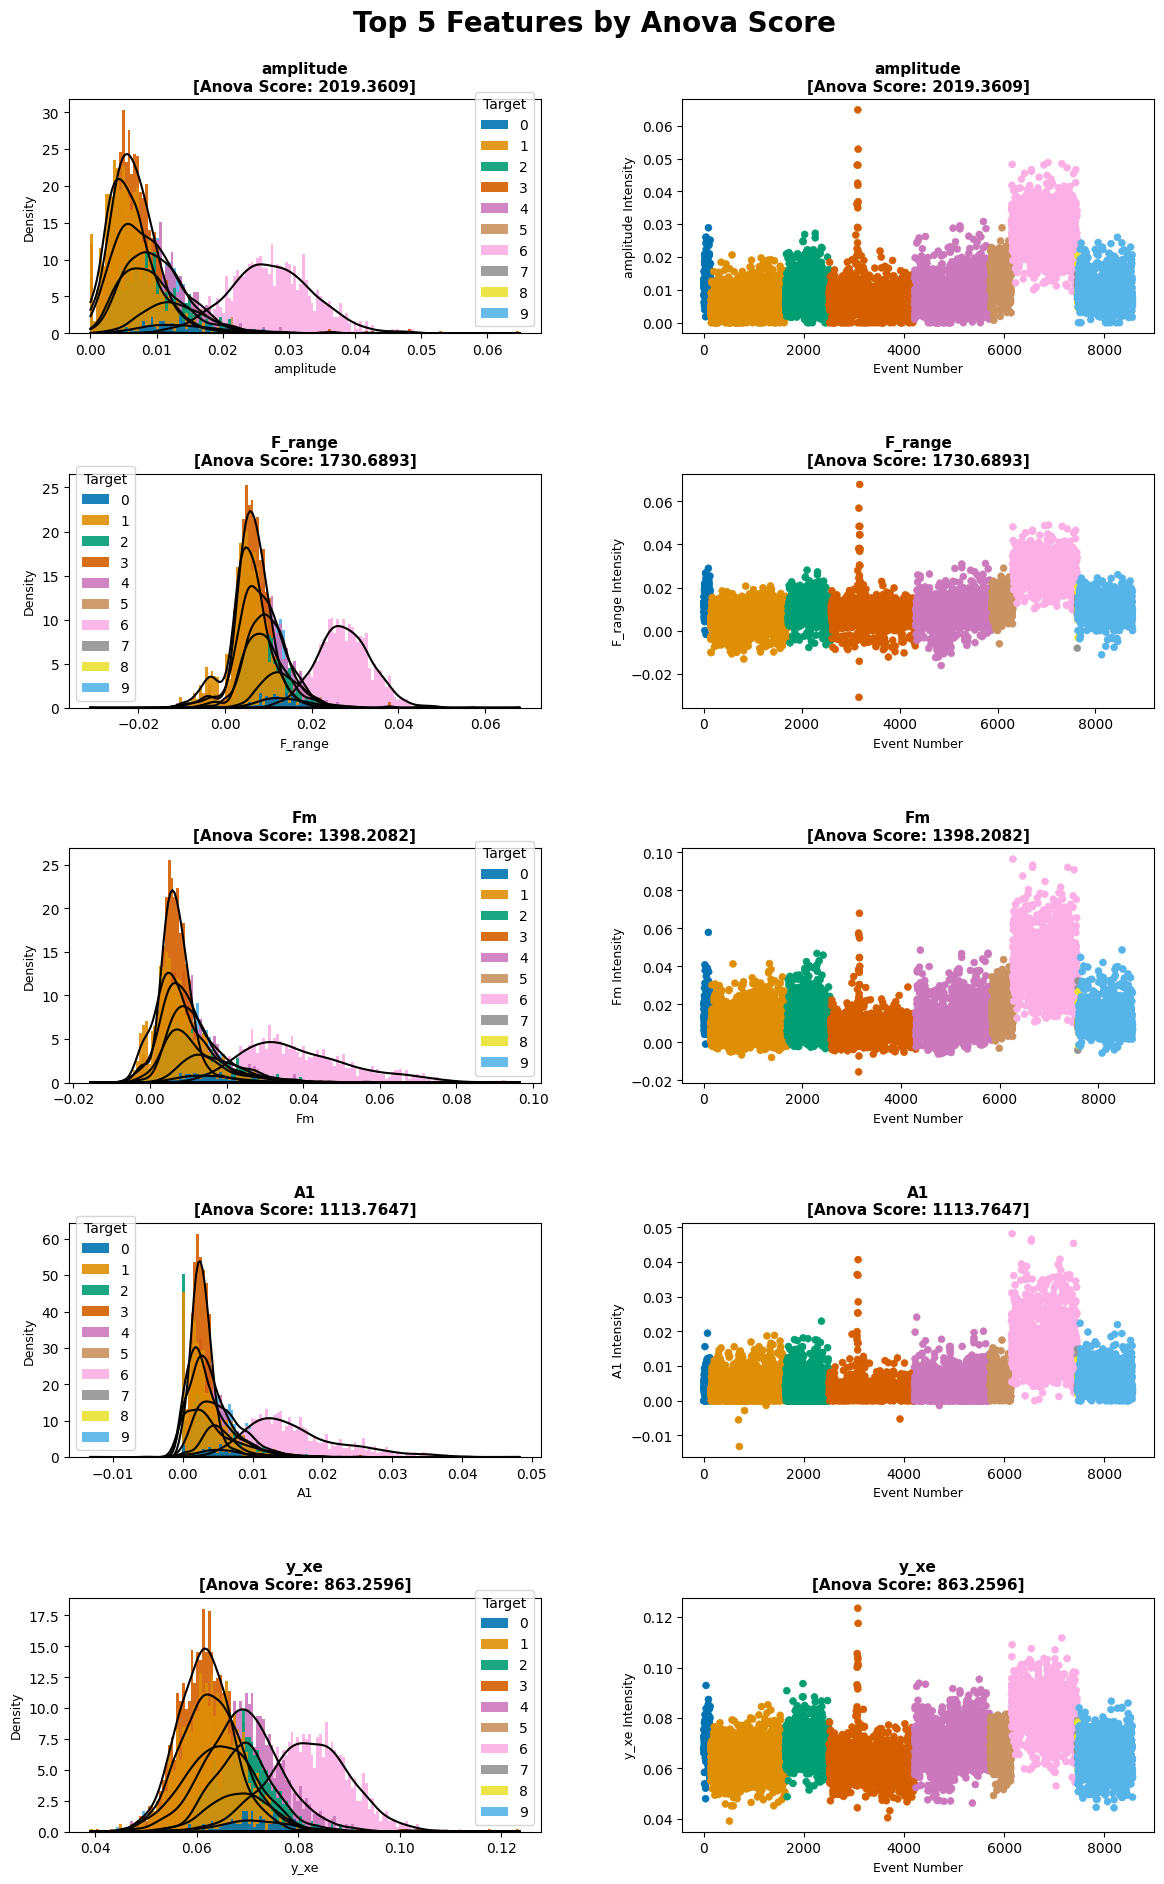

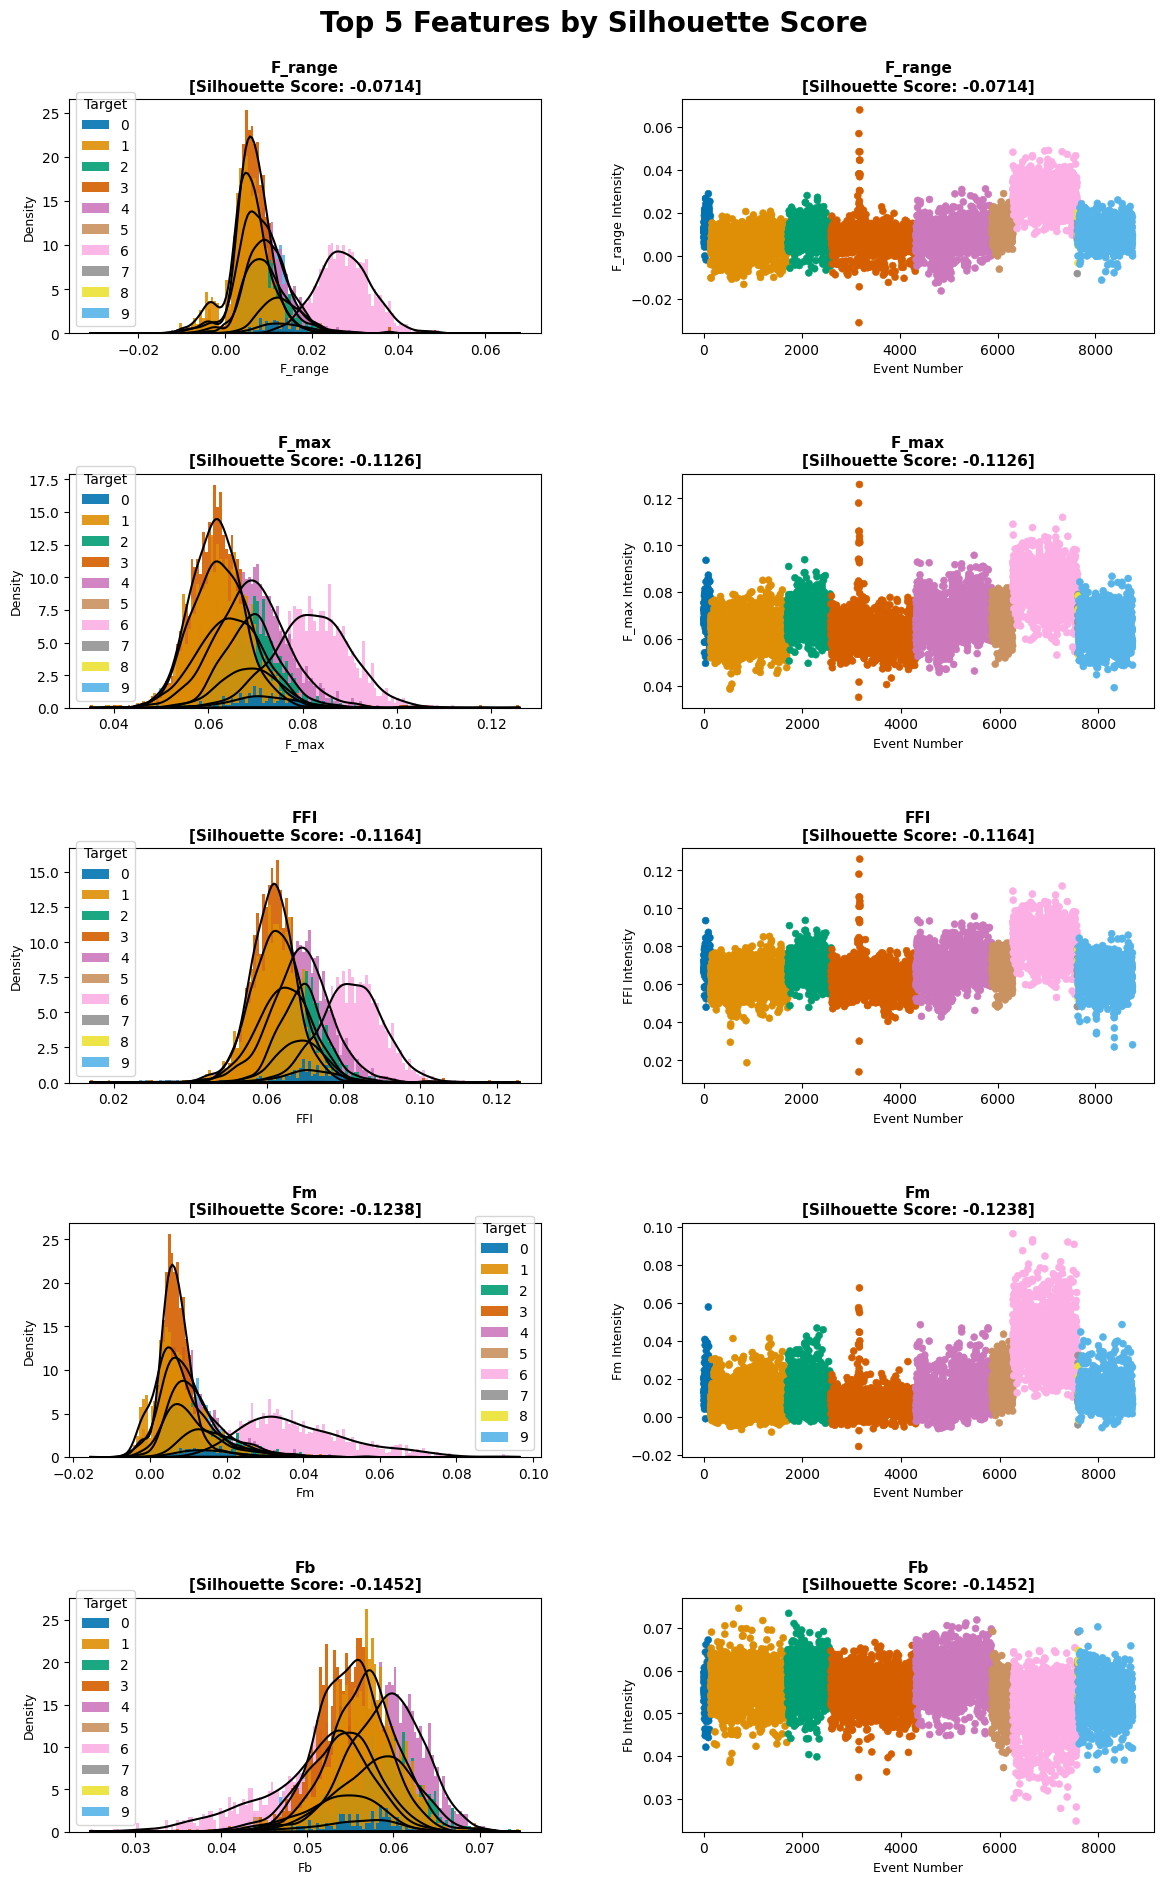

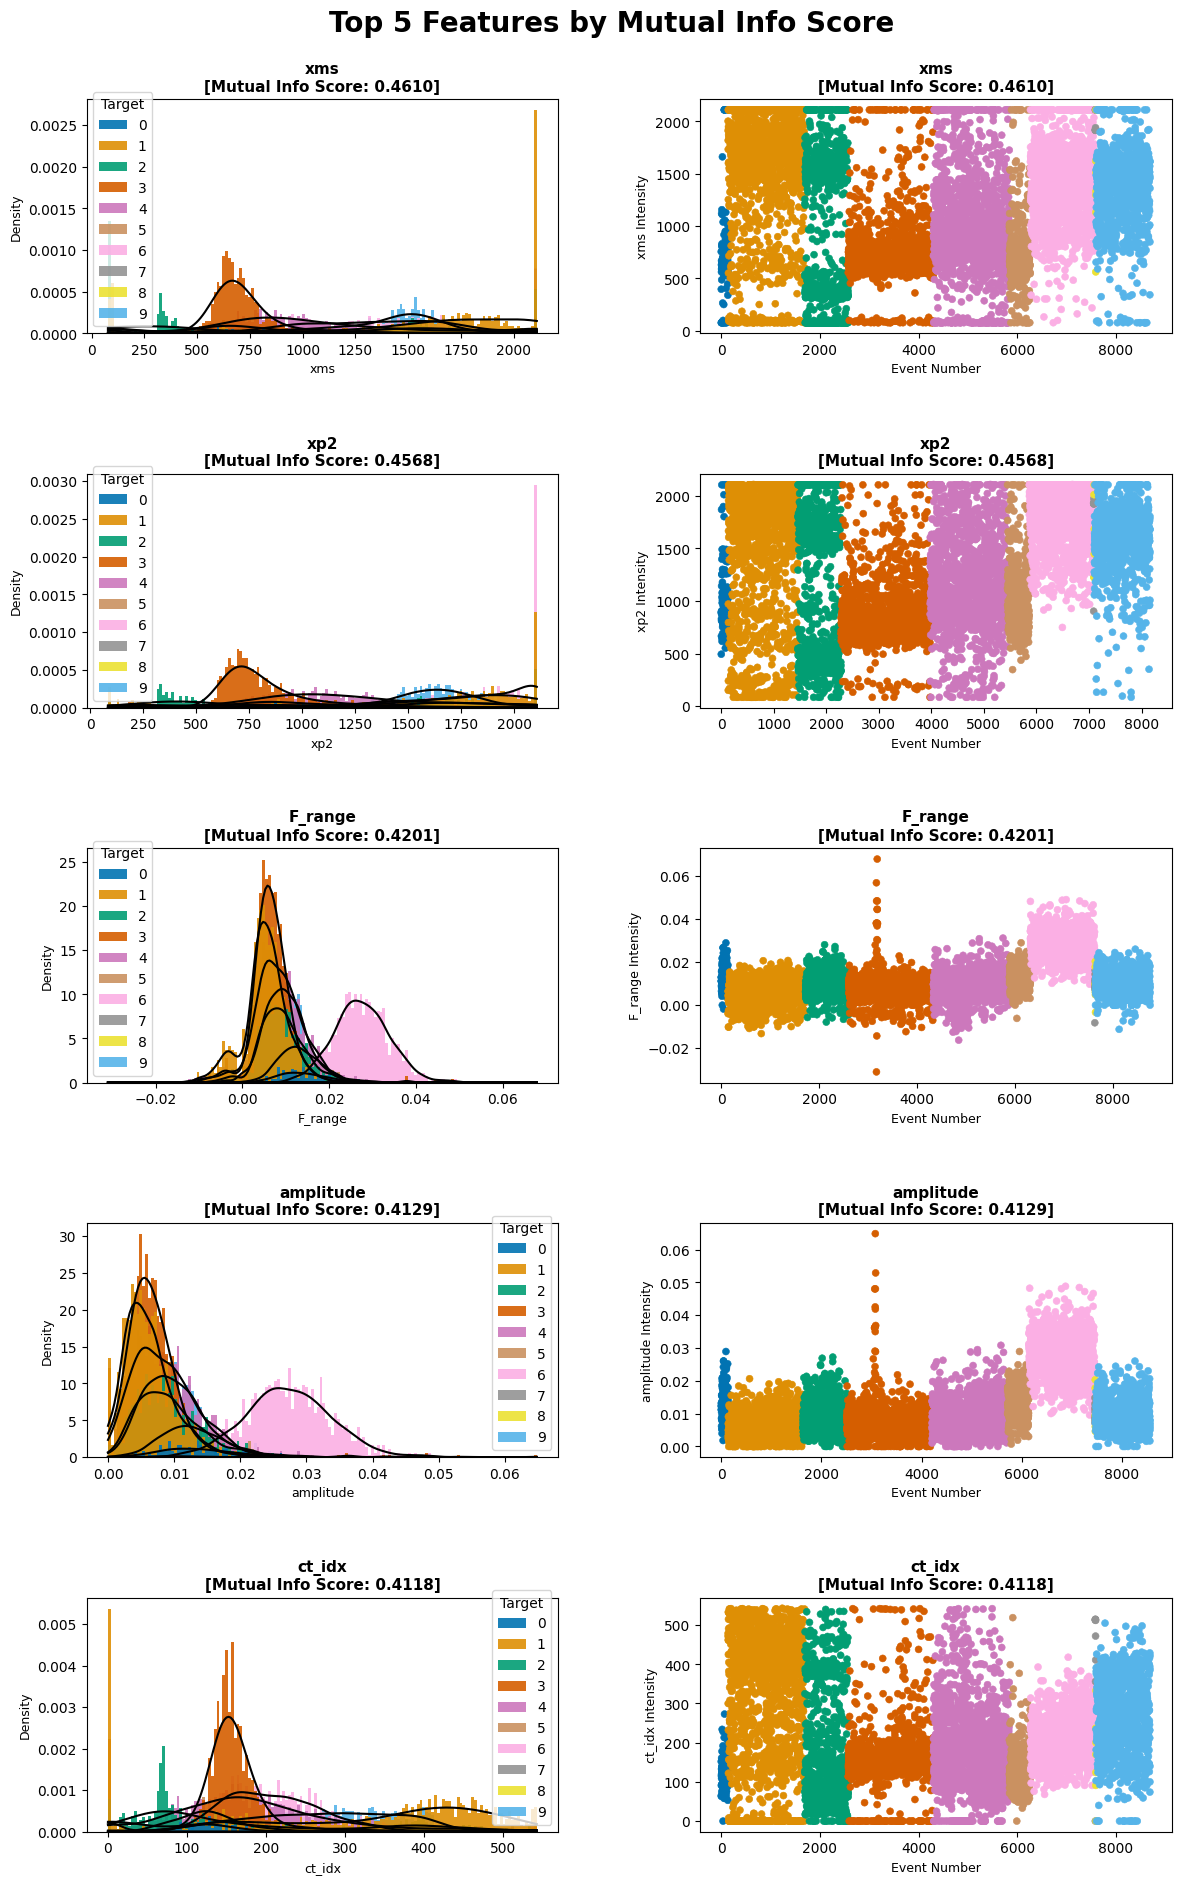

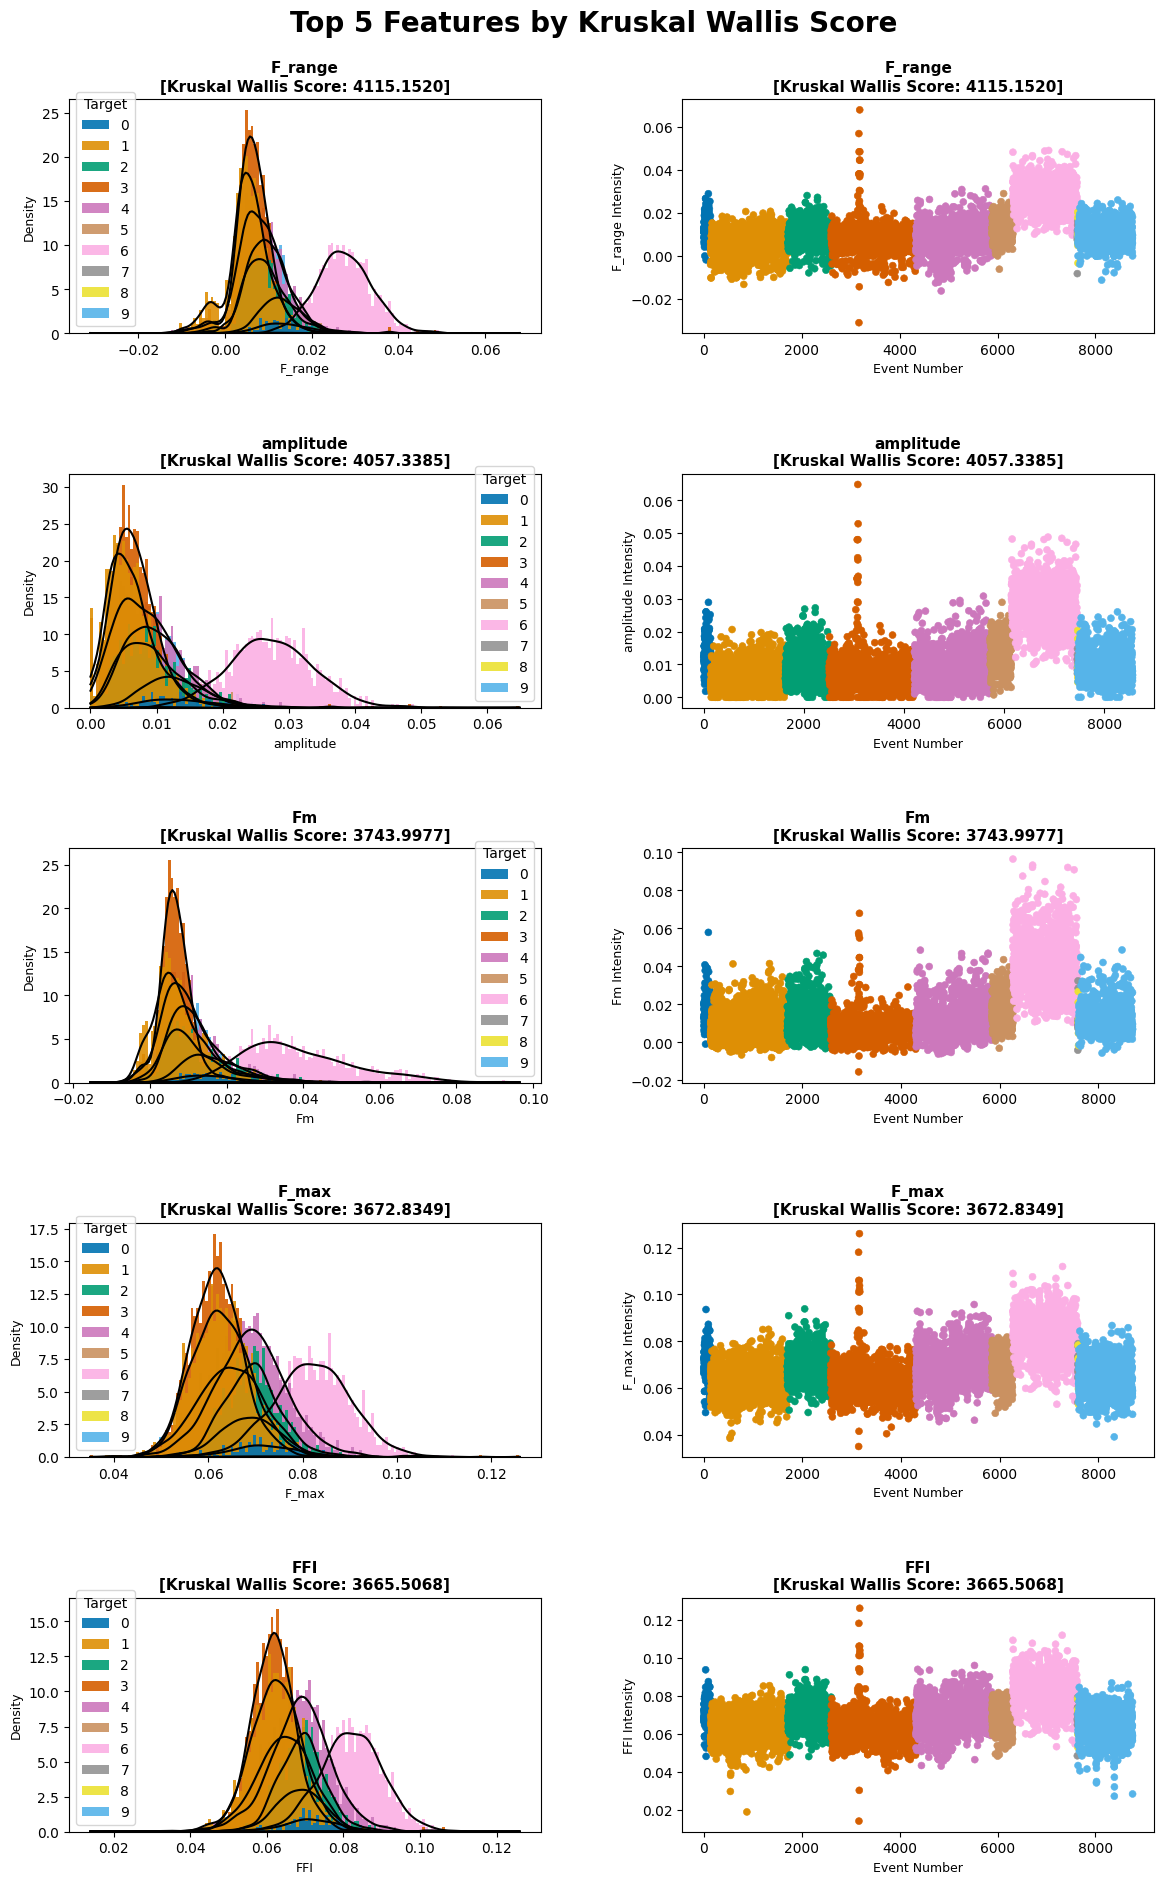

434895

In [128]:
SELECTED_DATASET_NAME = "D20250820_E00_C00_F4500KHz_U_Sample_18_wet_3"
SELECTED_CURVE_TYPE = "original_fitted_full"

dataset_idx = dataset_metadata["name"].index(SELECTED_DATASET_NAME)
curve_idx = curve_metadata["name"].index(SELECTED_CURVE_TYPE)
dataset_idx = 1
# 1. Get raw features and pre-calculated scores for this dataset/curve
selected_kf = dataset["kinetic_features"][dataset_idx][curve_idx]
selected_scores = dataset["feature_scores"][dataset_idx][curve_idx]
selected_y_well = np.array(dataset_metadata["Y_well"][dataset_idx])

top_n_ = 5

metrics = [
    "rf_importance", 
    "anova_score", 
    "silhouette_score", 
    "mutual_info_score", 
    "kruskal_wallis_score"
]

for m in metrics:
    sorted_scores = selected_scores.sort_values(by=m, ascending=False)
    
    valid_scores = sorted_scores[
        sorted_scores['feature'].isin(selected_kf.columns) & 
        ~sorted_scores['feature'].isin(EXCLUDED_FEATURES) &
        ~sorted_scores['feature'].str.contains('label') &
        ~sorted_scores['feature'].str.startswith('knn_top_')
    ].reset_index(drop=True)
    
    top_n_df = valid_scores.head(top_n_)
    
    fig, axes = plt.subplots(top_n_, 2, figsize=(14, top_n_ * 4.5))
    plt.subplots_adjust(hspace=0.6, wspace=0.3) 
    
    clean_metric_name = m.replace('_', ' ').title()
    
    for i in range(len(top_n_df)):
        feat = top_n_df.loc[i, 'feature']
        score_val = top_n_df.loc[i, m]
        feat_vals = selected_kf[feat].values
        
        title = f"{feat}\n[{clean_metric_name}: {score_val:.4f}]"
        
        ax_dist = axes[i, 0] if top_n_ > 1 else axes[0]
        ax_scat = axes[i, 1] if top_n_ > 1 else axes[1]
        
        plot_feature_visuals(ax_dist, ax_scat, feat, feat_vals, selected_y_well, title)
    
    fig.suptitle(f'Top {top_n_} Features by {clean_metric_name}', fontsize=20, fontweight='bold', y=0.92)

    plt.show()
    plt.close(fig)

gc.collect()